In [2]:
import os
import time
import psutil
import random

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve
)
from sklearn.utils.class_weight import compute_class_weight

from imblearn.over_sampling import BorderlineSMOTE


In [3]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

DATA_PATH = "/kaggle/input/datasets/saxenadivyansh/all-three/all_three.csv"

Using: cuda


In [4]:
# ----------------- Data Cleaning -----------------
def clean_dataframe(df):
    df = df.dropna(subset=["label"])
    df["label"] = df["label"].astype(int)
    df = df[df["label"] >= 0]
    return df

df = clean_dataframe(pd.read_csv(DATA_PATH))
print("Shape:", df.shape)


Shape: (427625, 25)


In [5]:
# ----------------- Custom Dataset -----------------
class CustomDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


In [6]:
# ----------------- Model (SOFTMAX FUSION) -----------------
class RobustParallelModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes):
        super().__init__()

        # CNN branch
        self.conv = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )
        self.cnn_fc = nn.Linear(64, hidden_dim)

        # LSTM branch
        self.lstm = nn.LSTM(input_size=1, hidden_size=hidden_dim, batch_first=True)
        self.lstm_fc = nn.Linear(hidden_dim, hidden_dim)

        # ✅ SOFTMAX FUSION
        self.fusion_layer = nn.Linear(hidden_dim * 2, 2)

        # Classifier
        self.classifier = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        # CNN
        cnn_in = x.unsqueeze(1)
        cnn_out = self.conv(cnn_in).squeeze(-1)
        cnn_feat = torch.relu(self.cnn_fc(cnn_out))

        # LSTM
        lstm_in = x.unsqueeze(-1)
        lstm_out, _ = self.lstm(lstm_in)
        lstm_feat = torch.relu(self.lstm_fc(lstm_out[:, -1, :]))

        # Softmax fusion
        combined = torch.cat([cnn_feat, lstm_feat], dim=1)
        weights = torch.softmax(self.fusion_layer(combined), dim=1)

        w_cnn = weights[:, 0].unsqueeze(1)
        w_lstm = weights[:, 1].unsqueeze(1)

        fused = w_cnn * cnn_feat + w_lstm * lstm_feat

        return self.classifier(fused)




In [7]:
# ----------------- Training -----------------
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for X, y in loader:
        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()
        logits = model(X)
        loss = criterion(logits, y)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()
        preds = torch.argmax(logits, dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    return total_loss / len(loader), correct / total



In [8]:
# ----------------- Evaluation -----------------
def evaluate(model, loader):
    model.eval()
    preds, true, probs = [], [], []

    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            logits = model(X)
            prob = torch.softmax(logits, dim=1)

            preds.extend(torch.argmax(prob, dim=1).cpu().numpy())
            true.extend(y.cpu().numpy())
            probs.extend(prob.cpu().numpy())

    preds, true, probs = map(np.array, (preds, true, probs))
    acc = accuracy_score(true, preds)

    num_classes = probs.shape[1]
    true_bin = label_binarize(true, classes=np.arange(num_classes))

    try:
        roc = roc_auc_score(true_bin, probs, multi_class='ovr', average='weighted')
    except:
        roc = np.nan

    return acc, roc, preds, true, probs


# Borderline SMOTE

In [11]:
def run_split(df, ratio_name, test_size, epochs=20):

    print(f"\n========== {ratio_name} ==========")

    start_time = time.time()
    process = psutil.Process(os.getpid())
    start_ram = process.memory_info().rss / (1024 ** 2)

    X = df.drop("label", axis=1).values
    y = df["label"].values
    num_classes = len(np.unique(y))

    # ----------------- ORIGINAL SIZE -----------------
    print("\n📊 Original Dataset Size:")
    print(f"Total Samples: {len(X)}")

    # ----------------- TRAIN TEST SPLIT -----------------
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=42
    )

    print("\n📊 After Train-Test Split:")
    print(f"Train Size: {X_train.shape}")
    print(f"Test Size : {X_test.shape}")

    # ----------------- BEFORE SMOTE -----------------
    print("\n📊 Before SMOTE:")
    print(f"Training Samples: {X_train.shape}")

    plt.figure(figsize=(6,4))
    pd.Series(y_train).value_counts().sort_index().plot(kind="bar")
    plt.title(f"{ratio_name} - BEFORE SMOTE")
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.show()

    print(pd.Series(y_train).value_counts().sort_index())

    # ----------------- BORDERLINE SMOTE -----------------
    try:
        smote = BorderlineSMOTE(random_state=42)
        X_train, y_train = smote.fit_resample(X_train, y_train)
    except Exception as e:
        print("SMOTE error:", e)

    # ----------------- AFTER SMOTE -----------------
    print("\n📊 After SMOTE:")
    print(f"Training Samples: {X_train.shape}")

    plt.figure(figsize=(6,4))
    pd.Series(y_train).value_counts().sort_index().plot(kind="bar", color="orange")
    plt.title(f"{ratio_name} - AFTER SMOTE")
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.show()

    print(pd.Series(y_train).value_counts().sort_index())

    # ----------------- SCALING -----------------
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # ----------------- LOADERS -----------------
    train_loader = DataLoader(CustomDataset(X_train, y_train), batch_size=64, shuffle=True)
    test_loader = DataLoader(CustomDataset(X_test, y_test), batch_size=64)

    # ----------------- MODEL -----------------
    model = RobustParallelModel(X.shape[1], 64, num_classes).to(device)

    class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
    class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    history = {"loss": [], "train_acc": [], "val_acc": []}

    # ----------------- TRAINING LOOP -----------------
    for epoch in range(epochs):
        loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
        val_acc, roc_auc, preds, true, probs = evaluate(model, test_loader)

        history["loss"].append(loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}: Loss={loss:.4f}, TrainAcc={train_acc:.4f}, TestAcc={val_acc:.4f}, ROC-AUC={roc_auc:.4f}")

    # ----------------- LOSS & ACCURACY -----------------
    fig, ax1 = plt.subplots(figsize=(10,5))
    ax1.plot(history["loss"], label="Loss", color="red")
    ax2 = ax1.twinx()
    ax2.plot(history["train_acc"], label="Train Acc")
    ax2.plot(history["val_acc"], label="Val Acc")
    ax1.legend(loc="upper left")
    ax2.legend(loc="upper right")
    plt.title(f"{ratio_name} Loss & Accuracy")
    plt.show()

    # ----------------- CONFUSION MATRIX -----------------
    cm = confusion_matrix(true, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{ratio_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    print(classification_report(true, preds))

    # ----------------- ROC CURVE -----------------
    y_test_bin = label_binarize(true, classes=np.arange(num_classes))
    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], probs[:, i])
        plt.plot(fpr, tpr, label=f"Class {i}")
    plt.legend()
    plt.title(f"{ratio_name} ROC Curve")
    plt.show()

    # ----------------- PRECISION-RECALL -----------------
    for i in range(num_classes):
        precision, recall, _ = precision_recall_curve(y_test_bin[:, i], probs[:, i])
        plt.plot(recall, precision, label=f"Class {i}")
    plt.legend()
    plt.title(f"{ratio_name} Precision-Recall")
    plt.show()

    # ----------------- STATS -----------------
    end_time = time.time()
    end_ram = process.memory_info().rss / (1024 ** 2)

    print(f"\nRuntime: {end_time - start_time:.2f}s")
    print(f"RAM Used: {end_ram - start_ram:.2f} MB")


========== 60:40 ==========

📊 Original Dataset Size:
Total Samples: 427625

📊 After Train-Test Split:
Train Size: (256575, 24)
Test Size : (171050, 24)

📊 Before SMOTE:
Training Samples: (256575, 24)


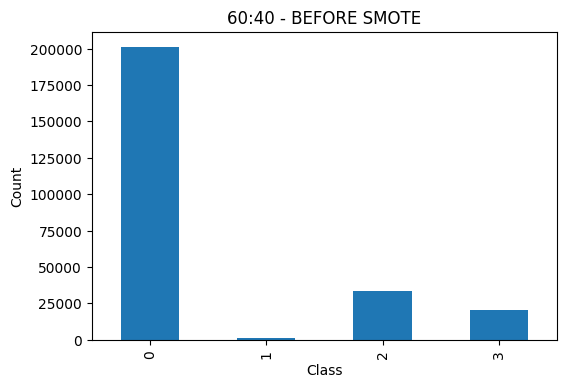

0    201508
1      1353
2     33234
3     20480
Name: count, dtype: int64

📊 After SMOTE:
Training Samples: (806032, 24)


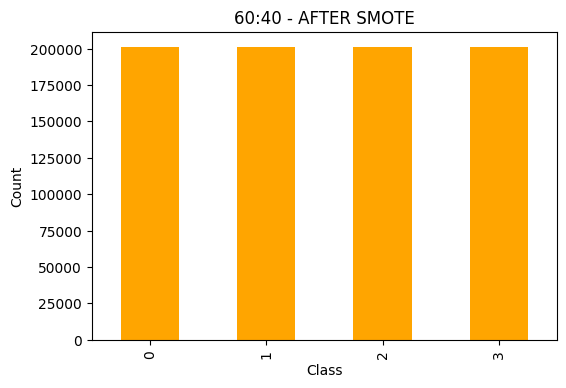

0    201508
1    201508
2    201508
3    201508
Name: count, dtype: int64
Epoch 1: Loss=0.1616, TrainAcc=0.9391, TestAcc=0.9662, ROC-AUC=0.9984
Epoch 2: Loss=0.0462, TrainAcc=0.9850, TestAcc=0.9770, ROC-AUC=0.9991
Epoch 3: Loss=0.0332, TrainAcc=0.9898, TestAcc=0.9789, ROC-AUC=0.9994
Epoch 4: Loss=0.0277, TrainAcc=0.9915, TestAcc=0.9790, ROC-AUC=0.9994
Epoch 5: Loss=0.0249, TrainAcc=0.9925, TestAcc=0.9828, ROC-AUC=0.9995
Epoch 6: Loss=0.0232, TrainAcc=0.9931, TestAcc=0.9838, ROC-AUC=0.9995
Epoch 7: Loss=0.0219, TrainAcc=0.9935, TestAcc=0.9843, ROC-AUC=0.9995
Epoch 8: Loss=0.0206, TrainAcc=0.9938, TestAcc=0.9847, ROC-AUC=0.9995
Epoch 9: Loss=0.0202, TrainAcc=0.9940, TestAcc=0.9809, ROC-AUC=0.9994
Epoch 10: Loss=0.0193, TrainAcc=0.9942, TestAcc=0.9846, ROC-AUC=0.9995
Epoch 11: Loss=0.0187, TrainAcc=0.9944, TestAcc=0.9855, ROC-AUC=0.9995
Epoch 12: Loss=0.0184, TrainAcc=0.9945, TestAcc=0.9850, ROC-AUC=0.9995
Epoch 13: Loss=0.0182, TrainAcc=0.9946, TestAcc=0.9852, ROC-AUC=0.9995
Epoch 14: Lo

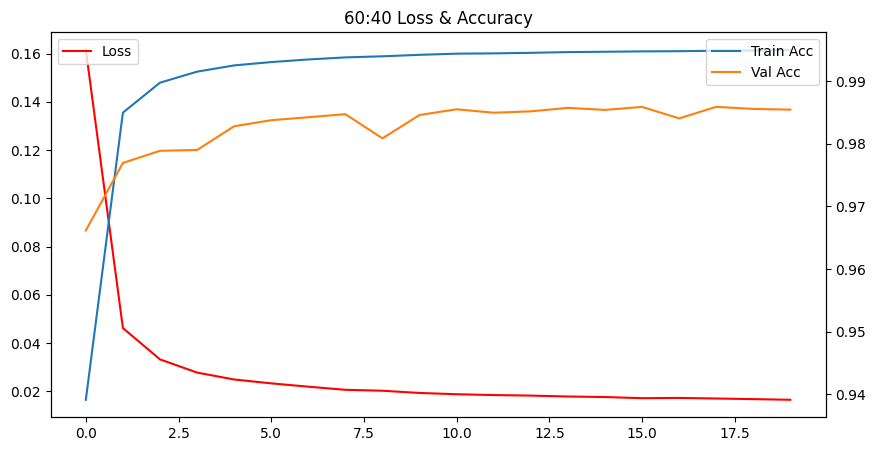

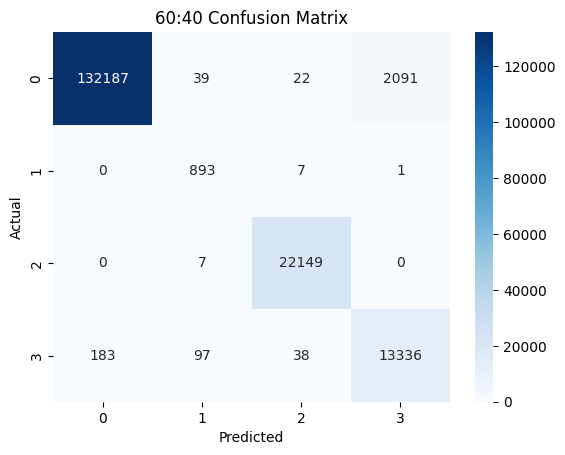

              precision    recall  f1-score   support

           0       1.00      0.98      0.99    134339
           1       0.86      0.99      0.92       901
           2       1.00      1.00      1.00     22156
           3       0.86      0.98      0.92     13654

    accuracy                           0.99    171050
   macro avg       0.93      0.99      0.96    171050
weighted avg       0.99      0.99      0.99    171050



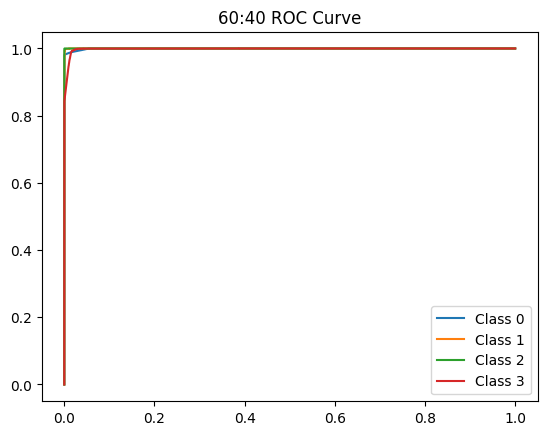

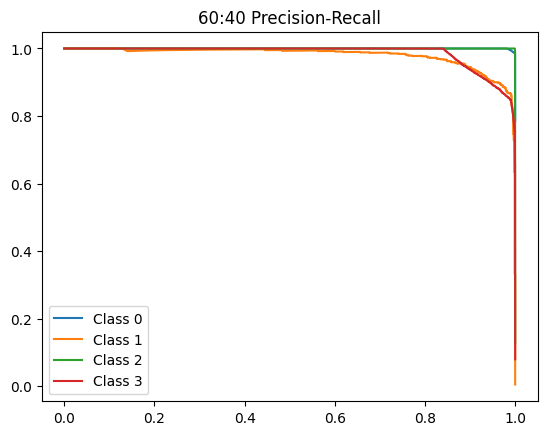


Runtime: 1228.13s
RAM Used: 440.00 MB

========== 70:30 ==========

📊 Original Dataset Size:
Total Samples: 427625

📊 After Train-Test Split:
Train Size: (299337, 24)
Test Size : (128288, 24)

📊 Before SMOTE:
Training Samples: (299337, 24)


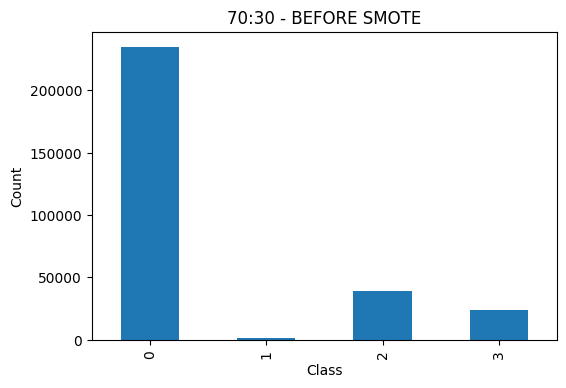

0    235092
1      1578
2     38773
3     23894
Name: count, dtype: int64

📊 After SMOTE:
Training Samples: (940368, 24)


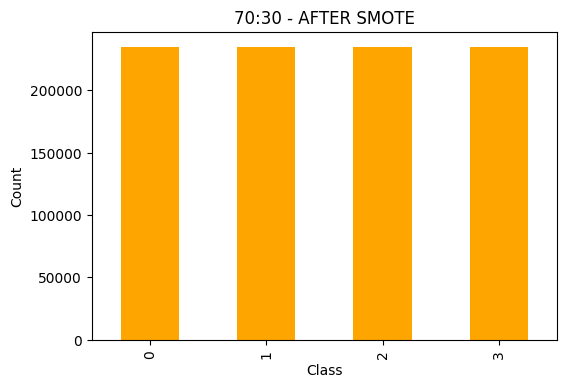

0    235092
1    235092
2    235092
3    235092
Name: count, dtype: int64
Epoch 1: Loss=0.1629, TrainAcc=0.9405, TestAcc=0.9686, ROC-AUC=0.9986
Epoch 2: Loss=0.0484, TrainAcc=0.9850, TestAcc=0.9782, ROC-AUC=0.9992
Epoch 3: Loss=0.0331, TrainAcc=0.9897, TestAcc=0.9792, ROC-AUC=0.9993
Epoch 4: Loss=0.0281, TrainAcc=0.9915, TestAcc=0.9841, ROC-AUC=0.9994
Epoch 5: Loss=0.0252, TrainAcc=0.9925, TestAcc=0.9839, ROC-AUC=0.9995
Epoch 6: Loss=0.0226, TrainAcc=0.9932, TestAcc=0.9846, ROC-AUC=0.9995
Epoch 7: Loss=0.0211, TrainAcc=0.9937, TestAcc=0.9852, ROC-AUC=0.9995
Epoch 8: Loss=0.0203, TrainAcc=0.9940, TestAcc=0.9855, ROC-AUC=0.9996
Epoch 9: Loss=0.0194, TrainAcc=0.9943, TestAcc=0.9848, ROC-AUC=0.9996
Epoch 10: Loss=0.0188, TrainAcc=0.9944, TestAcc=0.9861, ROC-AUC=0.9996
Epoch 11: Loss=0.0184, TrainAcc=0.9945, TestAcc=0.9849, ROC-AUC=0.9996
Epoch 12: Loss=0.0179, TrainAcc=0.9946, TestAcc=0.9860, ROC-AUC=0.9996
Epoch 13: Loss=0.0176, TrainAcc=0.9947, TestAcc=0.9856, ROC-AUC=0.9996
Epoch 14: Lo

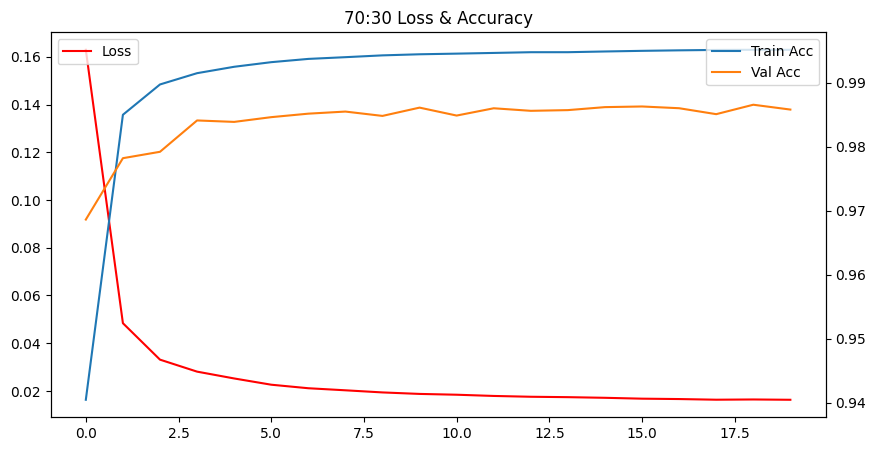

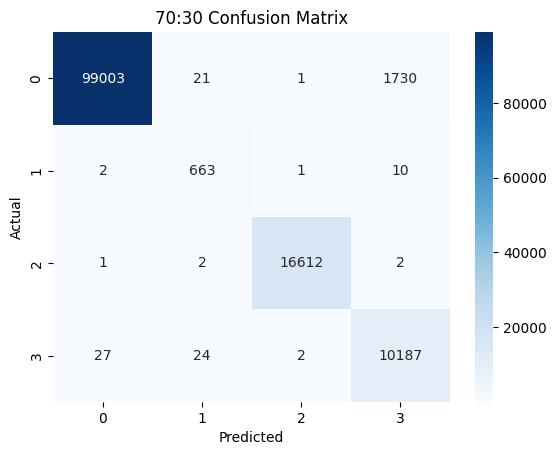

              precision    recall  f1-score   support

           0       1.00      0.98      0.99    100755
           1       0.93      0.98      0.96       676
           2       1.00      1.00      1.00     16617
           3       0.85      0.99      0.92     10240

    accuracy                           0.99    128288
   macro avg       0.95      0.99      0.97    128288
weighted avg       0.99      0.99      0.99    128288



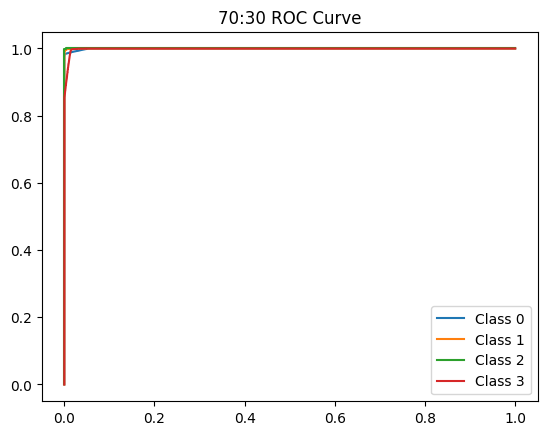

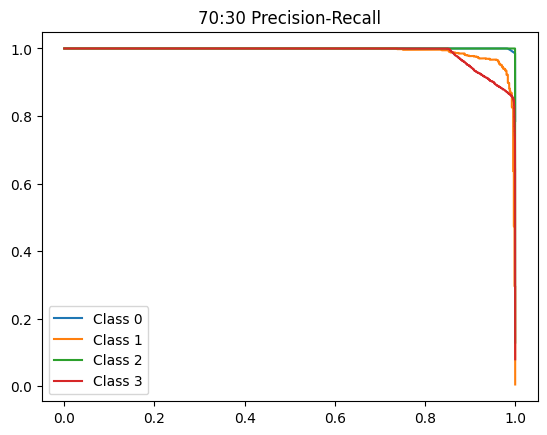


Runtime: 1396.26s
RAM Used: 408.41 MB

========== 80:20 ==========

📊 Original Dataset Size:
Total Samples: 427625

📊 After Train-Test Split:
Train Size: (342100, 24)
Test Size : (85525, 24)

📊 Before SMOTE:
Training Samples: (342100, 24)


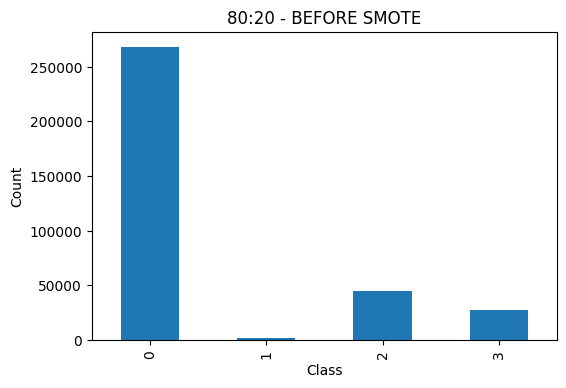

0    268678
1      1803
2     44312
3     27307
Name: count, dtype: int64

📊 After SMOTE:
Training Samples: (1074712, 24)


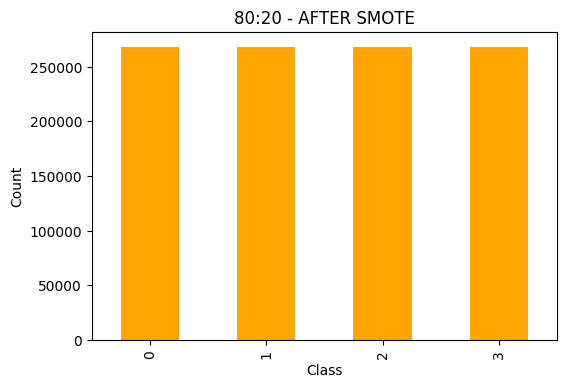

0    268678
1    268678
2    268678
3    268678
Name: count, dtype: int64
Epoch 1: Loss=0.1623, TrainAcc=0.9417, TestAcc=0.9805, ROC-AUC=0.9989
Epoch 2: Loss=0.0431, TrainAcc=0.9869, TestAcc=0.9798, ROC-AUC=0.9994
Epoch 3: Loss=0.0297, TrainAcc=0.9910, TestAcc=0.9775, ROC-AUC=0.9992
Epoch 4: Loss=0.0251, TrainAcc=0.9926, TestAcc=0.9830, ROC-AUC=0.9994
Epoch 5: Loss=0.0232, TrainAcc=0.9932, TestAcc=0.9850, ROC-AUC=0.9995
Epoch 6: Loss=0.0215, TrainAcc=0.9937, TestAcc=0.9827, ROC-AUC=0.9995
Epoch 7: Loss=0.0203, TrainAcc=0.9940, TestAcc=0.9858, ROC-AUC=0.9995
Epoch 8: Loss=0.0198, TrainAcc=0.9942, TestAcc=0.9842, ROC-AUC=0.9995
Epoch 9: Loss=0.0191, TrainAcc=0.9943, TestAcc=0.9858, ROC-AUC=0.9995
Epoch 10: Loss=0.0186, TrainAcc=0.9945, TestAcc=0.9856, ROC-AUC=0.9995
Epoch 11: Loss=0.0182, TrainAcc=0.9946, TestAcc=0.9861, ROC-AUC=0.9995
Epoch 12: Loss=0.0178, TrainAcc=0.9947, TestAcc=0.9861, ROC-AUC=0.9996
Epoch 13: Loss=0.0175, TrainAcc=0.9948, TestAcc=0.9857, ROC-AUC=0.9996
Epoch 14: Lo

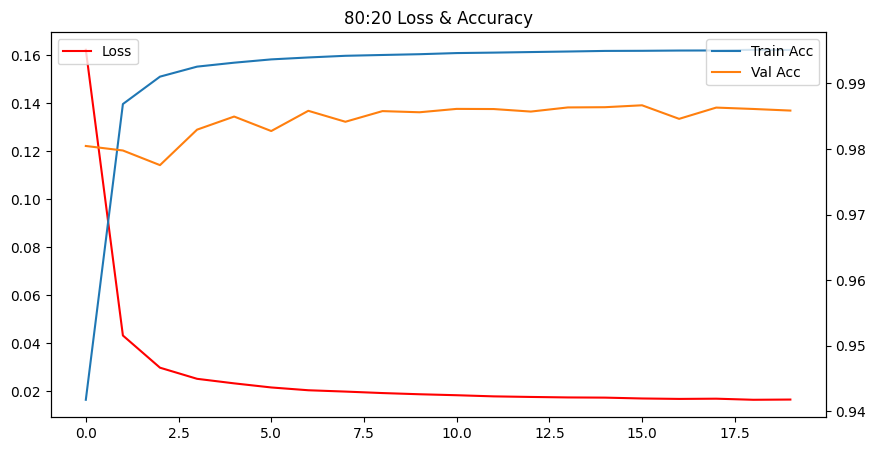

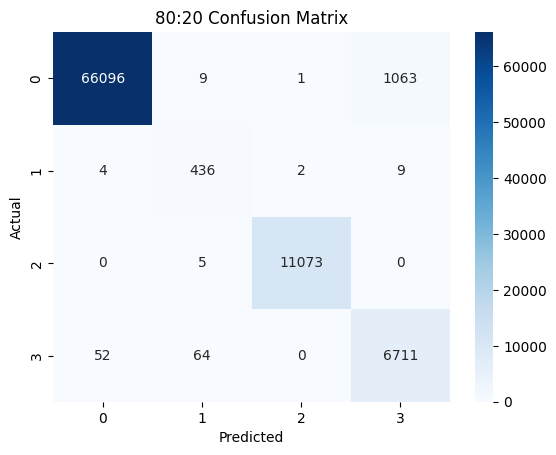

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     67169
           1       0.85      0.97      0.90       451
           2       1.00      1.00      1.00     11078
           3       0.86      0.98      0.92      6827

    accuracy                           0.99     85525
   macro avg       0.93      0.98      0.95     85525
weighted avg       0.99      0.99      0.99     85525



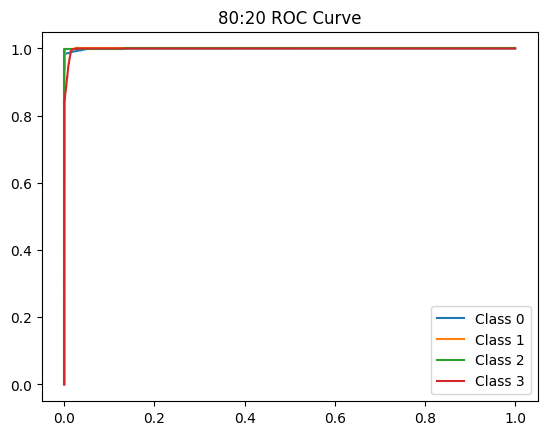

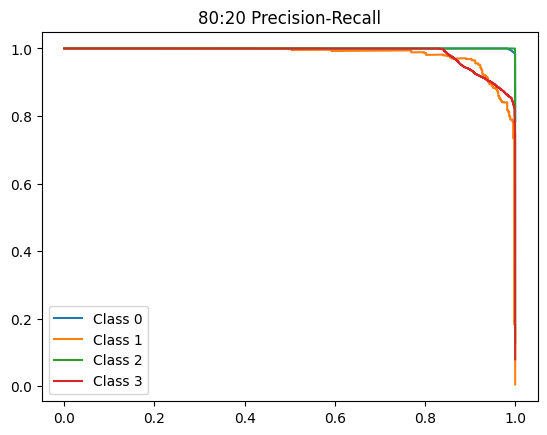


Runtime: 1568.48s
RAM Used: 451.82 MB


In [12]:
# ----------------- RUN -----------------
df = clean_dataframe(pd.read_csv(DATA_PATH))

run_split(df, "60:40", 0.4)
run_split(df, "70:30", 0.3)
run_split(df, "80:20", 0.2)

# SMOTE

In [13]:
from imblearn.over_sampling import SMOTE

def run_split_smote(df, ratio_name, test_size, epochs=20):

    print(f"\n========== {ratio_name} ==========")

    start_time = time.time()
    process = psutil.Process(os.getpid())
    start_ram = process.memory_info().rss / (1024 ** 2)

    X = df.drop("label", axis=1).values
    y = df["label"].values
    num_classes = len(np.unique(y))

    # ----------------- ORIGINAL SIZE -----------------
    print("\n📊 Original Dataset Size:")
    print(f"Total Samples: {len(X)}")

    # ----------------- TRAIN TEST SPLIT -----------------
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=42
    )

    print("\n📊 After Train-Test Split:")
    print(f"Train Size: {X_train.shape}")
    print(f"Test Size : {X_test.shape}")

    # ----------------- BEFORE SMOTE -----------------
    print("\n📊 Before SMOTE:")
    print(f"Training Samples: {X_train.shape}")

    plt.figure(figsize=(6,4))
    pd.Series(y_train).value_counts().sort_index().plot(kind="bar")
    plt.title(f"{ratio_name} - BEFORE SMOTE")
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.show()

    print(pd.Series(y_train).value_counts().sort_index())

    # ----------------- STANDARD SMOTE -----------------
    try:
        smote = SMOTE(random_state=42)
        X_train, y_train = smote.fit_resample(X_train, y_train)
    except Exception as e:
        print("SMOTE error:", e)

    # ----------------- AFTER SMOTE -----------------
    print("\n📊 After SMOTE:")
    print(f"Training Samples: {X_train.shape}")

    plt.figure(figsize=(6,4))
    pd.Series(y_train).value_counts().sort_index().plot(kind="bar", color="orange")
    plt.title(f"{ratio_name} - AFTER SMOTE")
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.show()

    print(pd.Series(y_train).value_counts().sort_index())

    # ----------------- SCALING -----------------
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # ----------------- LOADERS -----------------
    train_loader = DataLoader(CustomDataset(X_train, y_train), batch_size=64, shuffle=True)
    test_loader = DataLoader(CustomDataset(X_test, y_test), batch_size=64)

    # ----------------- MODEL -----------------
    model = RobustParallelModel(X.shape[1], 64, num_classes).to(device)

    class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
    class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    history = {"loss": [], "train_acc": [], "val_acc": []}

    # ----------------- TRAINING LOOP -----------------
    for epoch in range(epochs):
        loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
        val_acc, roc_auc, preds, true, probs = evaluate(model, test_loader)

        history["loss"].append(loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}: Loss={loss:.4f}, TrainAcc={train_acc:.4f}, TestAcc={val_acc:.4f}, ROC-AUC={roc_auc:.4f}")

    # ----------------- LOSS & ACCURACY -----------------
    fig, ax1 = plt.subplots(figsize=(10,5))
    ax1.plot(history["loss"], label="Loss", color="red")

    ax2 = ax1.twinx()
    ax2.plot(history["train_acc"], label="Train Acc")
    ax2.plot(history["val_acc"], label="Val Acc")

    ax1.legend(loc="upper left")
    ax2.legend(loc="upper right")

    plt.title(f"{ratio_name} Loss & Accuracy")
    plt.show()

    # ----------------- CONFUSION MATRIX -----------------
    cm = confusion_matrix(true, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{ratio_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    print(classification_report(true, preds))

    # ----------------- ROC CURVE -----------------
    y_test_bin = label_binarize(true, classes=np.arange(num_classes))

    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], probs[:, i])
        plt.plot(fpr, tpr, label=f"Class {i}")

    plt.legend()
    plt.title(f"{ratio_name} ROC Curve")
    plt.show()

    # ----------------- PRECISION-RECALL -----------------
    for i in range(num_classes):
        precision, recall, _ = precision_recall_curve(y_test_bin[:, i], probs[:, i])
        plt.plot(recall, precision, label=f"Class {i}")

    plt.legend()
    plt.title(f"{ratio_name} Precision-Recall")
    plt.show()

    # ----------------- STATS -----------------
    end_time = time.time()
    end_ram = process.memory_info().rss / (1024 ** 2)

    print(f"\nRuntime: {end_time - start_time:.2f}s")
    print(f"RAM Used: {end_ram - start_ram:.2f} MB")


========== 60:40 ==========

📊 Original Dataset Size:
Total Samples: 427625

📊 After Train-Test Split:
Train Size: (256575, 24)
Test Size : (171050, 24)

📊 Before SMOTE:
Training Samples: (256575, 24)


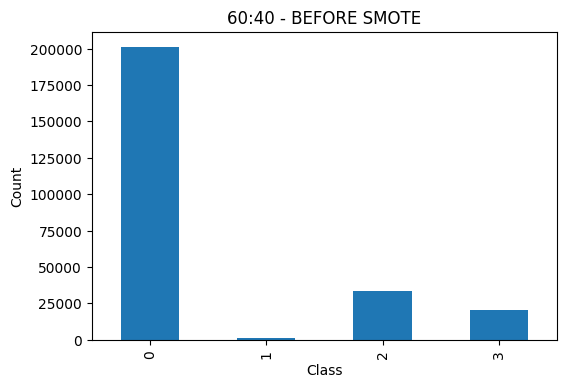

0    201508
1      1353
2     33234
3     20480
Name: count, dtype: int64

📊 After SMOTE:
Training Samples: (806032, 24)


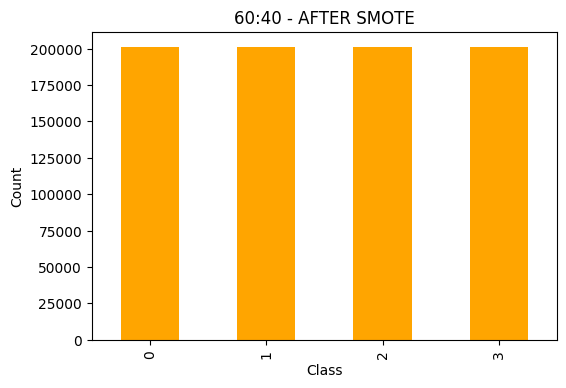

0    201508
1    201508
2    201508
3    201508
Name: count, dtype: int64
Epoch 1: Loss=0.1318, TrainAcc=0.9502, TestAcc=0.9699, ROC-AUC=0.9986
Epoch 2: Loss=0.0396, TrainAcc=0.9868, TestAcc=0.9818, ROC-AUC=0.9993
Epoch 3: Loss=0.0297, TrainAcc=0.9902, TestAcc=0.9783, ROC-AUC=0.9994
Epoch 4: Loss=0.0253, TrainAcc=0.9917, TestAcc=0.9816, ROC-AUC=0.9994
Epoch 5: Loss=0.0229, TrainAcc=0.9925, TestAcc=0.9843, ROC-AUC=0.9995
Epoch 6: Loss=0.0210, TrainAcc=0.9931, TestAcc=0.9821, ROC-AUC=0.9994
Epoch 7: Loss=0.0201, TrainAcc=0.9935, TestAcc=0.9858, ROC-AUC=0.9995
Epoch 8: Loss=0.0193, TrainAcc=0.9936, TestAcc=0.9845, ROC-AUC=0.9995
Epoch 9: Loss=0.0186, TrainAcc=0.9939, TestAcc=0.9857, ROC-AUC=0.9995
Epoch 10: Loss=0.0177, TrainAcc=0.9941, TestAcc=0.9849, ROC-AUC=0.9995
Epoch 11: Loss=0.0174, TrainAcc=0.9942, TestAcc=0.9846, ROC-AUC=0.9994
Epoch 12: Loss=0.0173, TrainAcc=0.9943, TestAcc=0.9851, ROC-AUC=0.9995
Epoch 13: Loss=0.0169, TrainAcc=0.9944, TestAcc=0.9855, ROC-AUC=0.9995
Epoch 14: Lo

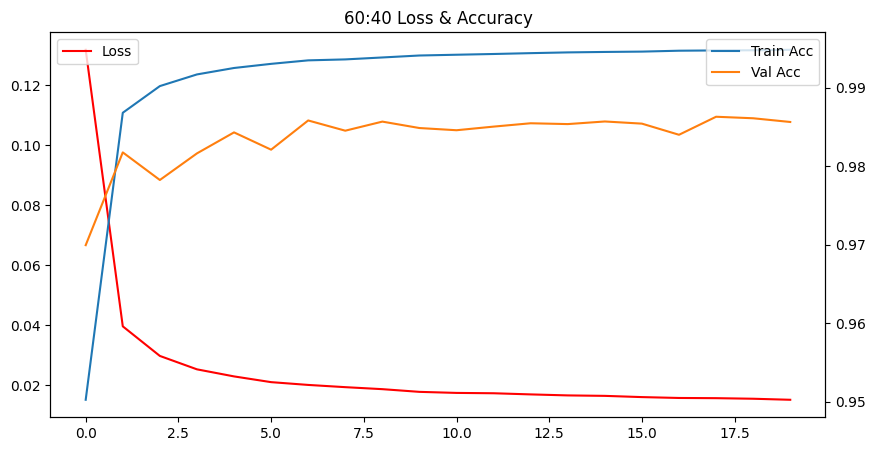

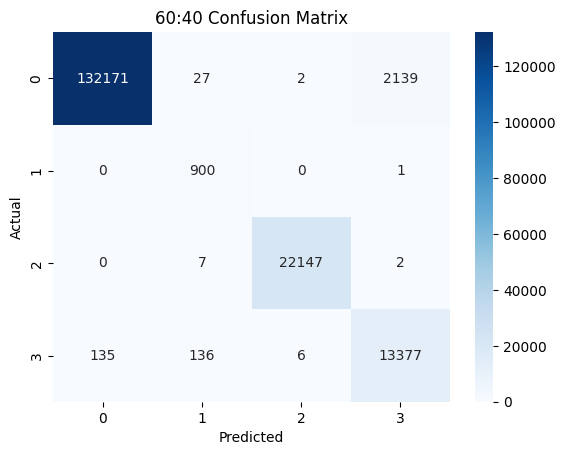

              precision    recall  f1-score   support

           0       1.00      0.98      0.99    134339
           1       0.84      1.00      0.91       901
           2       1.00      1.00      1.00     22156
           3       0.86      0.98      0.92     13654

    accuracy                           0.99    171050
   macro avg       0.93      0.99      0.96    171050
weighted avg       0.99      0.99      0.99    171050



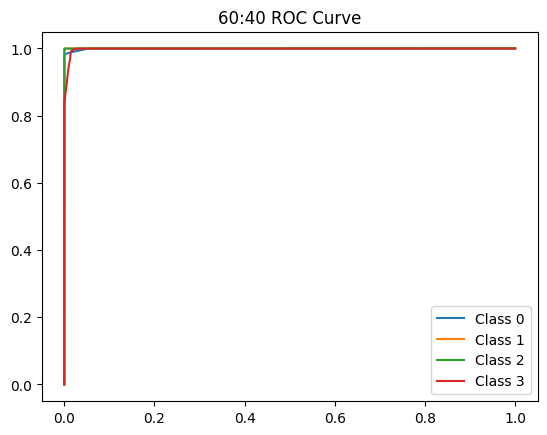

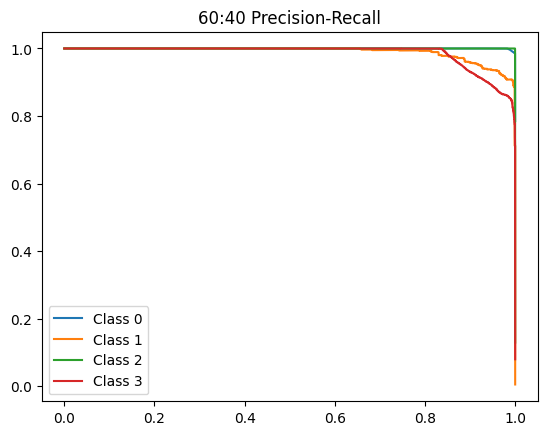


Runtime: 1189.81s
RAM Used: 317.12 MB

========== 70:30 ==========

📊 Original Dataset Size:
Total Samples: 427625

📊 After Train-Test Split:
Train Size: (299337, 24)
Test Size : (128288, 24)

📊 Before SMOTE:
Training Samples: (299337, 24)


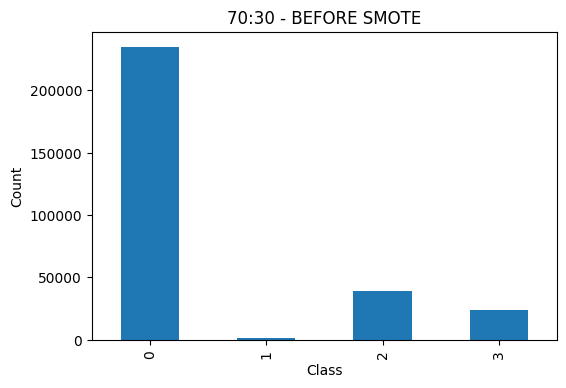

0    235092
1      1578
2     38773
3     23894
Name: count, dtype: int64

📊 After SMOTE:
Training Samples: (940368, 24)


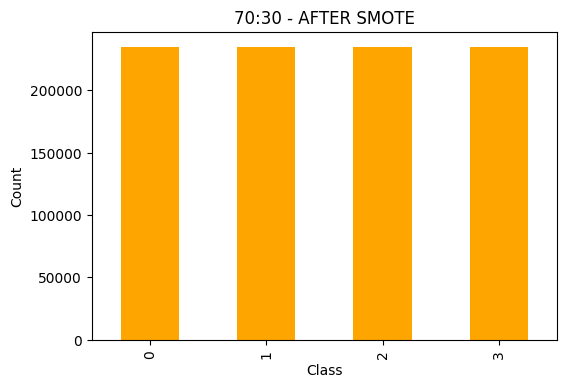

0    235092
1    235092
2    235092
3    235092
Name: count, dtype: int64
Epoch 1: Loss=0.1379, TrainAcc=0.9477, TestAcc=0.9735, ROC-AUC=0.9989
Epoch 2: Loss=0.0411, TrainAcc=0.9863, TestAcc=0.9744, ROC-AUC=0.9992
Epoch 3: Loss=0.0294, TrainAcc=0.9902, TestAcc=0.9836, ROC-AUC=0.9994
Epoch 4: Loss=0.0254, TrainAcc=0.9917, TestAcc=0.9820, ROC-AUC=0.9994
Epoch 5: Loss=0.0222, TrainAcc=0.9927, TestAcc=0.9841, ROC-AUC=0.9995
Epoch 6: Loss=0.0208, TrainAcc=0.9932, TestAcc=0.9854, ROC-AUC=0.9995
Epoch 7: Loss=0.0197, TrainAcc=0.9936, TestAcc=0.9846, ROC-AUC=0.9995
Epoch 8: Loss=0.0186, TrainAcc=0.9939, TestAcc=0.9852, ROC-AUC=0.9995
Epoch 9: Loss=0.0180, TrainAcc=0.9940, TestAcc=0.9850, ROC-AUC=0.9995
Epoch 10: Loss=0.0178, TrainAcc=0.9941, TestAcc=0.9848, ROC-AUC=0.9995
Epoch 11: Loss=0.0172, TrainAcc=0.9943, TestAcc=0.9848, ROC-AUC=0.9995
Epoch 12: Loss=0.0170, TrainAcc=0.9943, TestAcc=0.9853, ROC-AUC=0.9996
Epoch 13: Loss=0.0165, TrainAcc=0.9944, TestAcc=0.9856, ROC-AUC=0.9995
Epoch 14: Lo

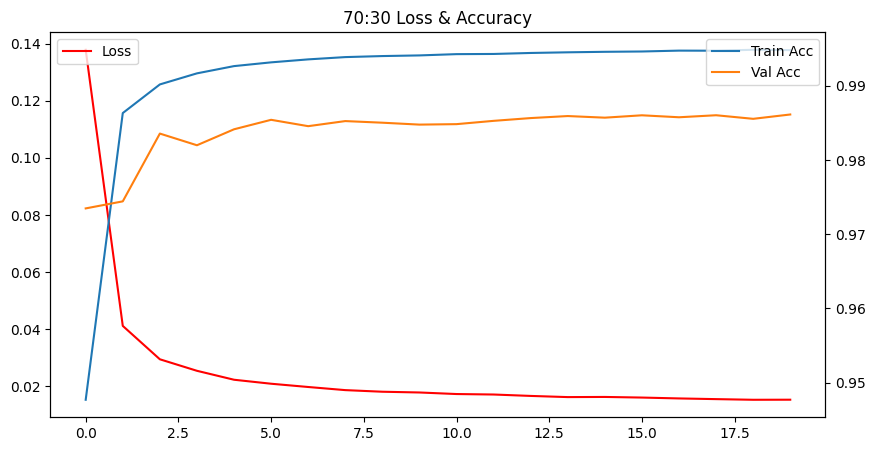

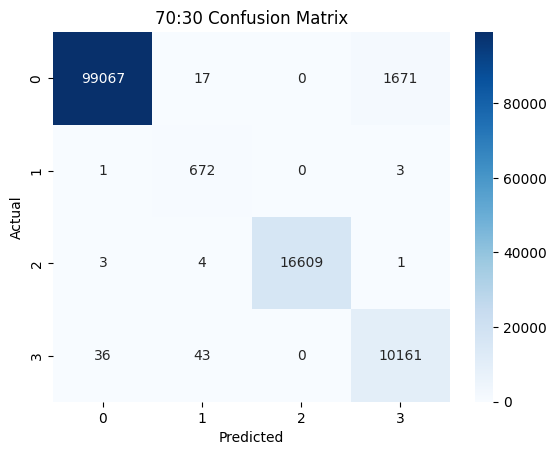

              precision    recall  f1-score   support

           0       1.00      0.98      0.99    100755
           1       0.91      0.99      0.95       676
           2       1.00      1.00      1.00     16617
           3       0.86      0.99      0.92     10240

    accuracy                           0.99    128288
   macro avg       0.94      0.99      0.97    128288
weighted avg       0.99      0.99      0.99    128288



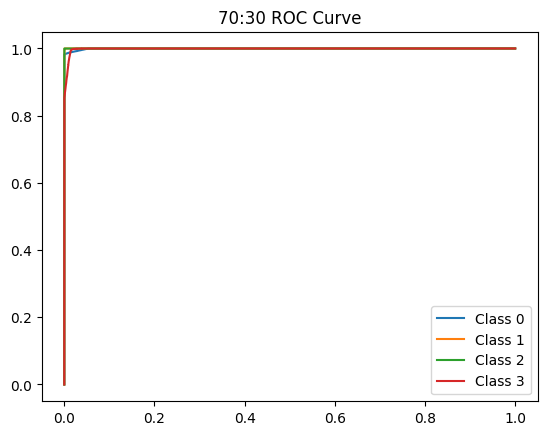

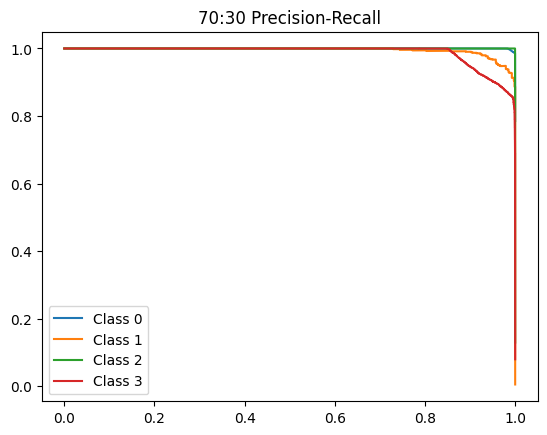


Runtime: 1357.44s
RAM Used: 341.51 MB

========== 80:20 ==========

📊 Original Dataset Size:
Total Samples: 427625

📊 After Train-Test Split:
Train Size: (342100, 24)
Test Size : (85525, 24)

📊 Before SMOTE:
Training Samples: (342100, 24)


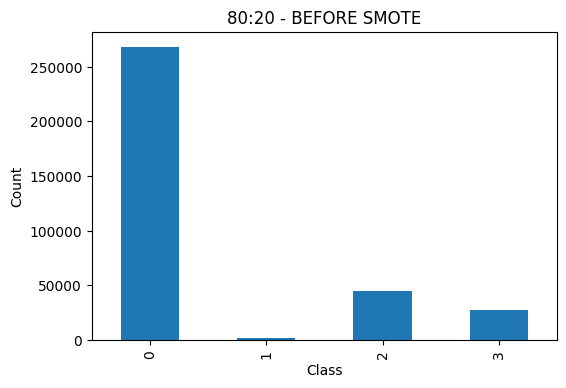

0    268678
1      1803
2     44312
3     27307
Name: count, dtype: int64

📊 After SMOTE:
Training Samples: (1074712, 24)


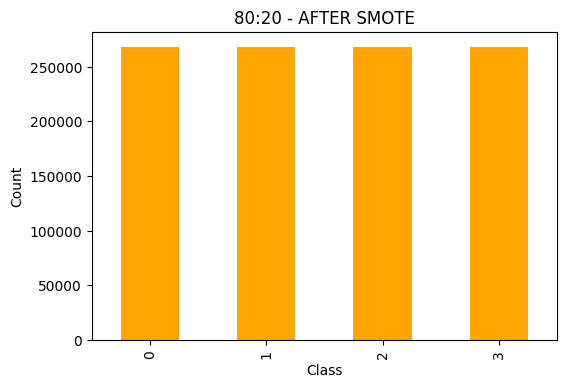

0    268678
1    268678
2    268678
3    268678
Name: count, dtype: int64
Epoch 1: Loss=0.1634, TrainAcc=0.9366, TestAcc=0.9713, ROC-AUC=0.9986
Epoch 2: Loss=0.0418, TrainAcc=0.9859, TestAcc=0.9755, ROC-AUC=0.9993
Epoch 3: Loss=0.0301, TrainAcc=0.9903, TestAcc=0.9797, ROC-AUC=0.9994
Epoch 4: Loss=0.0253, TrainAcc=0.9918, TestAcc=0.9833, ROC-AUC=0.9995
Epoch 5: Loss=0.0231, TrainAcc=0.9926, TestAcc=0.9845, ROC-AUC=0.9996
Epoch 6: Loss=0.0210, TrainAcc=0.9933, TestAcc=0.9809, ROC-AUC=0.9994
Epoch 7: Loss=0.0201, TrainAcc=0.9935, TestAcc=0.9838, ROC-AUC=0.9995
Epoch 8: Loss=0.0190, TrainAcc=0.9938, TestAcc=0.9853, ROC-AUC=0.9996
Epoch 9: Loss=0.0186, TrainAcc=0.9940, TestAcc=0.9847, ROC-AUC=0.9995
Epoch 11: Loss=0.0176, TrainAcc=0.9942, TestAcc=0.9852, ROC-AUC=0.9996
Epoch 12: Loss=0.0172, TrainAcc=0.9944, TestAcc=0.9865, ROC-AUC=0.9996
Epoch 13: Loss=0.0169, TrainAcc=0.9944, TestAcc=0.9859, ROC-AUC=0.9996
Epoch 14: Loss=0.0167, TrainAcc=0.9946, TestAcc=0.9862, ROC-AUC=0.9996
Epoch 15: Lo

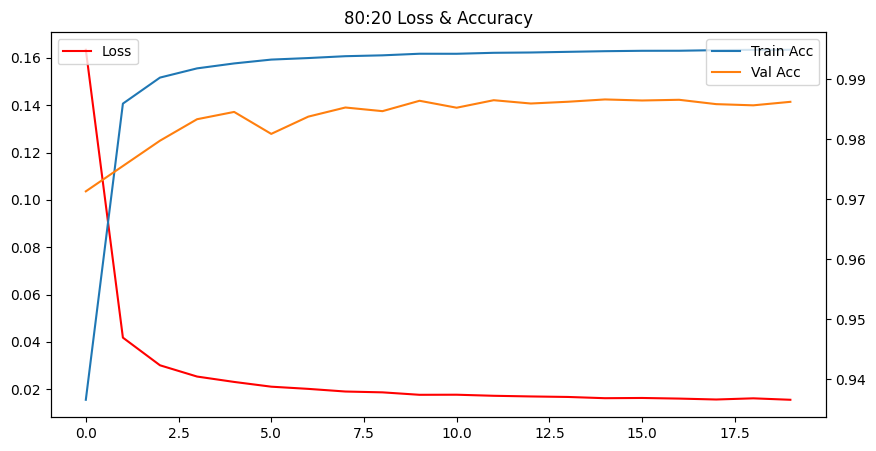

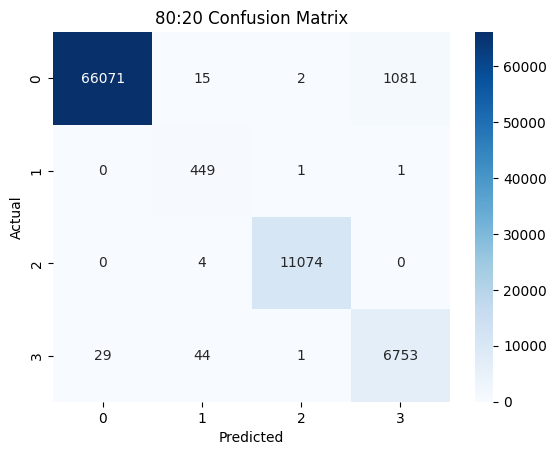

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     67169
           1       0.88      1.00      0.93       451
           2       1.00      1.00      1.00     11078
           3       0.86      0.99      0.92      6827

    accuracy                           0.99     85525
   macro avg       0.93      0.99      0.96     85525
weighted avg       0.99      0.99      0.99     85525



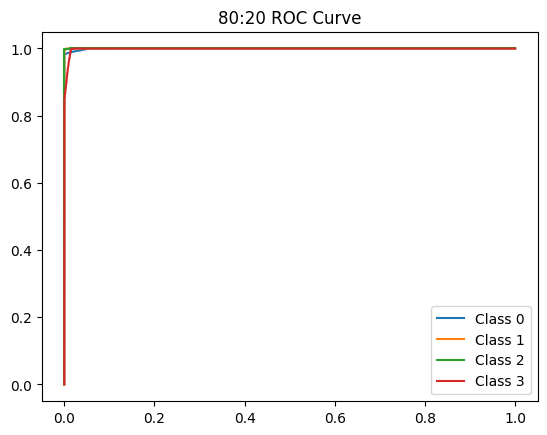

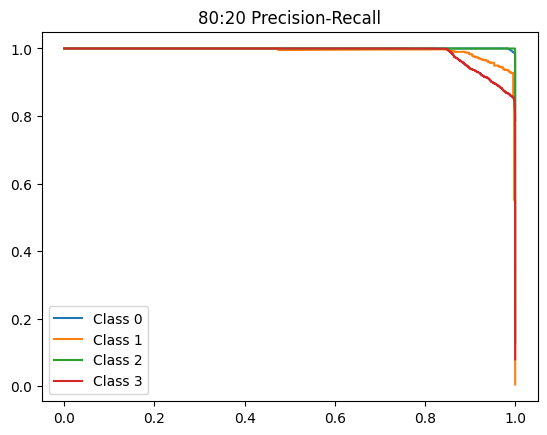


Runtime: 1522.21s
RAM Used: 378.55 MB


In [14]:
# ----------------- RUN -----------------
df = clean_dataframe(pd.read_csv(DATA_PATH))

run_split_smote(df, "60:40", 0.4)
run_split_smote(df, "70:30", 0.3)
run_split_smote(df, "80:20", 0.2)

# ADASYN

In [9]:
from imblearn.over_sampling import ADASYN

def run_split_adasyn(df, ratio_name, test_size, epochs=20):

    print(f"\n========== {ratio_name} ==========")

    start_time = time.time()
    process = psutil.Process(os.getpid())
    start_ram = process.memory_info().rss / (1024 ** 2)

    X = df.drop("label", axis=1).values
    y = df["label"].values
    num_classes = len(np.unique(y))

    # ----------------- ORIGINAL SIZE -----------------
    print("\n📊 Original Dataset Size:")
    print(f"Total Samples: {len(X)}")

    # ----------------- TRAIN TEST SPLIT -----------------
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=42
    )

    print("\n📊 After Train-Test Split:")
    print(f"Train Size: {X_train.shape}")
    print(f"Test Size : {X_test.shape}")

    # ----------------- BEFORE SAMPLING -----------------
    print("\n📊 Before ADASYN:")
    print(f"Training Samples: {X_train.shape}")

    plt.figure(figsize=(6,4))
    pd.Series(y_train).value_counts().sort_index().plot(kind="bar")
    plt.title(f"{ratio_name} - BEFORE ADASYN")
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.show()

    print(pd.Series(y_train).value_counts().sort_index())

    # ----------------- ADASYN -----------------
    try:
        adasyn = ADASYN(random_state=42)
        X_train, y_train = adasyn.fit_resample(X_train, y_train)
    except Exception as e:
        print("ADASYN error:", e)

    # ----------------- AFTER ADASYN -----------------
    print("\n📊 After ADASYN:")
    print(f"Training Samples: {X_train.shape}")

    plt.figure(figsize=(6,4))
    pd.Series(y_train).value_counts().sort_index().plot(kind="bar", color="orange")
    plt.title(f"{ratio_name} - AFTER ADASYN")
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.show()

    print(pd.Series(y_train).value_counts().sort_index())

    # ----------------- SCALING -----------------
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # ----------------- LOADERS -----------------
    train_loader = DataLoader(CustomDataset(X_train, y_train), batch_size=64, shuffle=True)
    test_loader = DataLoader(CustomDataset(X_test, y_test), batch_size=64)

    # ----------------- MODEL -----------------
    model = RobustParallelModel(X.shape[1], 64, num_classes).to(device)

    class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
    class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    history = {"loss": [], "train_acc": [], "val_acc": []}

    # ----------------- TRAINING LOOP -----------------
    for epoch in range(epochs):
        loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
        val_acc, roc_auc, preds, true, probs = evaluate(model, test_loader)

        history["loss"].append(loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}: Loss={loss:.4f}, TrainAcc={train_acc:.4f}, TestAcc={val_acc:.4f}, ROC-AUC={roc_auc:.4f}")

    # ----------------- LOSS & ACCURACY -----------------
    fig, ax1 = plt.subplots(figsize=(10,5))
    ax1.plot(history["loss"], label="Loss", color="red")

    ax2 = ax1.twinx()
    ax2.plot(history["train_acc"], label="Train Acc")
    ax2.plot(history["val_acc"], label="Val Acc")

    ax1.legend(loc="upper left")
    ax2.legend(loc="upper right")

    plt.title(f"{ratio_name} Loss & Accuracy")
    plt.show()

    # ----------------- CONFUSION MATRIX -----------------
    cm = confusion_matrix(true, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{ratio_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    print(classification_report(true, preds))

    # ----------------- ROC CURVE -----------------
    y_test_bin = label_binarize(true, classes=np.arange(num_classes))

    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], probs[:, i])
        plt.plot(fpr, tpr, label=f"Class {i}")

    plt.legend()
    plt.title(f"{ratio_name} ROC Curve")
    plt.show()

    # ----------------- PRECISION-RECALL -----------------
    for i in range(num_classes):
        precision, recall, _ = precision_recall_curve(y_test_bin[:, i], probs[:, i])
        plt.plot(recall, precision, label=f"Class {i}")

    plt.legend()
    plt.title(f"{ratio_name} Precision-Recall")
    plt.show()

    # ----------------- STATS -----------------
    end_time = time.time()
    end_ram = process.memory_info().rss / (1024 ** 2)

    print(f"\nRuntime: {end_time - start_time:.2f}s")
    print(f"RAM Used: {end_ram - start_ram:.2f} MB")


========== 60:40 ==========

📊 Original Dataset Size:
Total Samples: 427625

📊 After Train-Test Split:
Train Size: (256575, 24)
Test Size : (171050, 24)

📊 Before ADASYN:
Training Samples: (256575, 24)


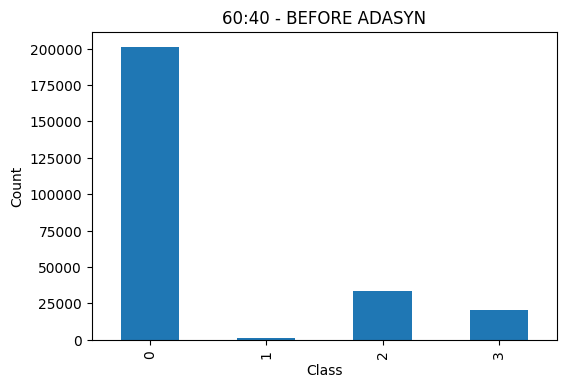

0    201508
1      1353
2     33234
3     20480
Name: count, dtype: int64

📊 After ADASYN:
Training Samples: (805442, 24)


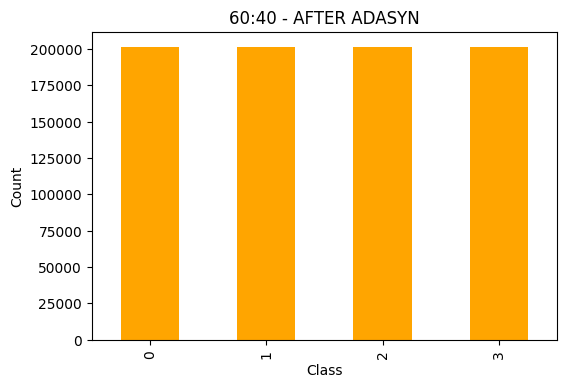

0    201508
1    201439
2    201546
3    200949
Name: count, dtype: int64
Epoch 1: Loss=0.1996, TrainAcc=0.9268, TestAcc=0.9722, ROC-AUC=0.9980
Epoch 2: Loss=0.0621, TrainAcc=0.9805, TestAcc=0.9776, ROC-AUC=0.9992
Epoch 3: Loss=0.0427, TrainAcc=0.9867, TestAcc=0.9824, ROC-AUC=0.9991
Epoch 4: Loss=0.0344, TrainAcc=0.9894, TestAcc=0.9754, ROC-AUC=0.9993
Epoch 5: Loss=0.0294, TrainAcc=0.9911, TestAcc=0.9797, ROC-AUC=0.9993
Epoch 6: Loss=0.0262, TrainAcc=0.9921, TestAcc=0.9839, ROC-AUC=0.9994
Epoch 7: Loss=0.0244, TrainAcc=0.9926, TestAcc=0.9844, ROC-AUC=0.9995
Epoch 8: Loss=0.0225, TrainAcc=0.9931, TestAcc=0.9847, ROC-AUC=0.9995
Epoch 9: Loss=0.0217, TrainAcc=0.9934, TestAcc=0.9838, ROC-AUC=0.9995
Epoch 10: Loss=0.0207, TrainAcc=0.9936, TestAcc=0.9850, ROC-AUC=0.9995
Epoch 11: Loss=0.0199, TrainAcc=0.9939, TestAcc=0.9839, ROC-AUC=0.9995
Epoch 12: Loss=0.0195, TrainAcc=0.9940, TestAcc=0.9855, ROC-AUC=0.9995
Epoch 13: Loss=0.0191, TrainAcc=0.9941, TestAcc=0.9851, ROC-AUC=0.9995
Epoch 14: Lo

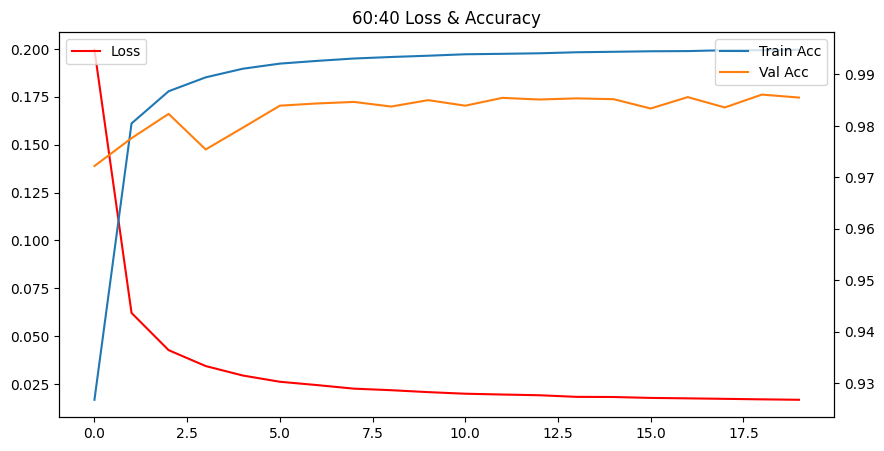

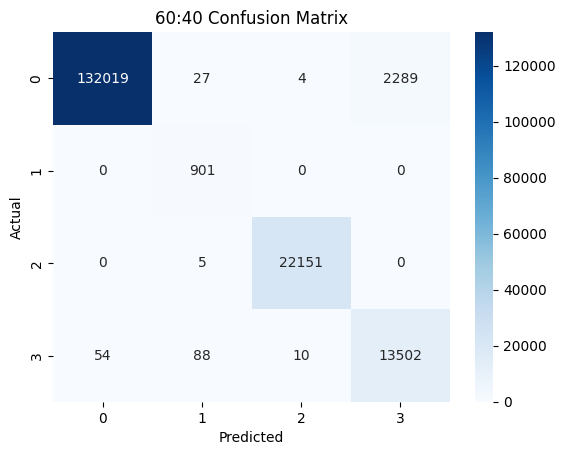

              precision    recall  f1-score   support

           0       1.00      0.98      0.99    134339
           1       0.88      1.00      0.94       901
           2       1.00      1.00      1.00     22156
           3       0.86      0.99      0.92     13654

    accuracy                           0.99    171050
   macro avg       0.93      0.99      0.96    171050
weighted avg       0.99      0.99      0.99    171050



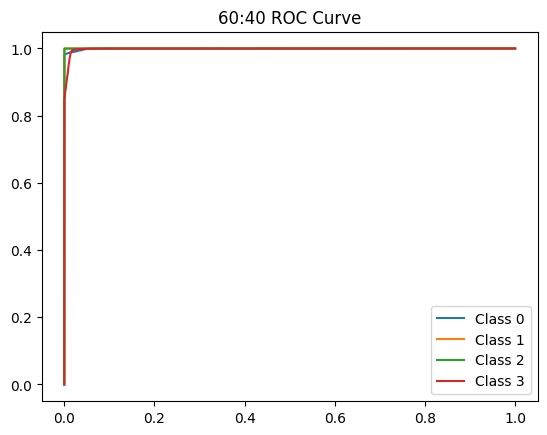

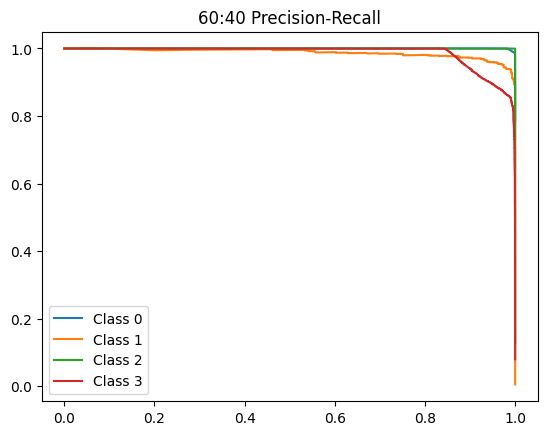


Runtime: 1272.56s
RAM Used: 321.86 MB

========== 70:30 ==========

📊 Original Dataset Size:
Total Samples: 427625

📊 After Train-Test Split:
Train Size: (299337, 24)
Test Size : (128288, 24)

📊 Before ADASYN:
Training Samples: (299337, 24)


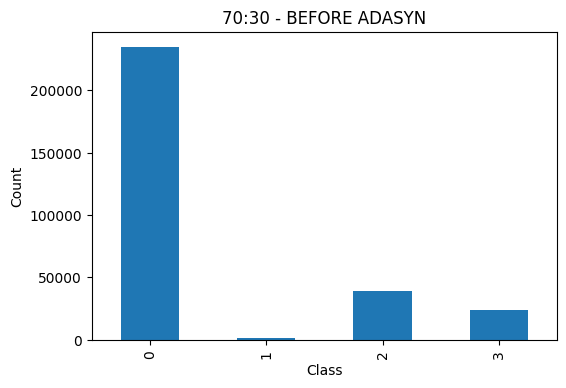

0    235092
1      1578
2     38773
3     23894
Name: count, dtype: int64

📊 After ADASYN:
Training Samples: (942085, 24)


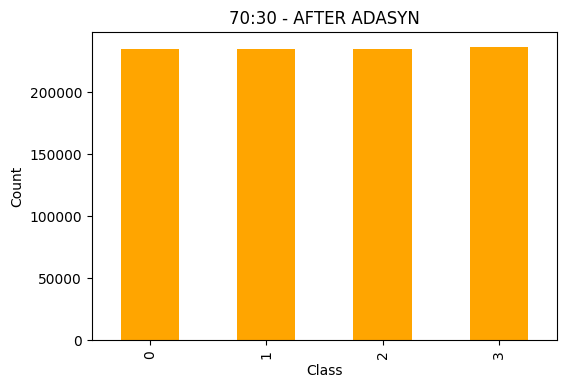

0    235092
1    235149
2    235089
3    236755
Name: count, dtype: int64
Epoch 1: Loss=0.2046, TrainAcc=0.9216, TestAcc=0.9711, ROC-AUC=0.9991
Epoch 2: Loss=0.0546, TrainAcc=0.9822, TestAcc=0.9761, ROC-AUC=0.9993
Epoch 3: Loss=0.0375, TrainAcc=0.9882, TestAcc=0.9802, ROC-AUC=0.9994
Epoch 4: Loss=0.0306, TrainAcc=0.9906, TestAcc=0.9845, ROC-AUC=0.9995
Epoch 5: Loss=0.0265, TrainAcc=0.9919, TestAcc=0.9834, ROC-AUC=0.9995
Epoch 6: Loss=0.0243, TrainAcc=0.9927, TestAcc=0.9832, ROC-AUC=0.9995
Epoch 7: Loss=0.0227, TrainAcc=0.9931, TestAcc=0.9845, ROC-AUC=0.9995
Epoch 8: Loss=0.0214, TrainAcc=0.9935, TestAcc=0.9847, ROC-AUC=0.9995
Epoch 9: Loss=0.0206, TrainAcc=0.9937, TestAcc=0.9857, ROC-AUC=0.9995
Epoch 10: Loss=0.0202, TrainAcc=0.9939, TestAcc=0.9847, ROC-AUC=0.9996
Epoch 11: Loss=0.0195, TrainAcc=0.9941, TestAcc=0.9864, ROC-AUC=0.9996
Epoch 12: Loss=0.0190, TrainAcc=0.9942, TestAcc=0.9840, ROC-AUC=0.9995
Epoch 13: Loss=0.0188, TrainAcc=0.9942, TestAcc=0.9865, ROC-AUC=0.9996
Epoch 14: Lo

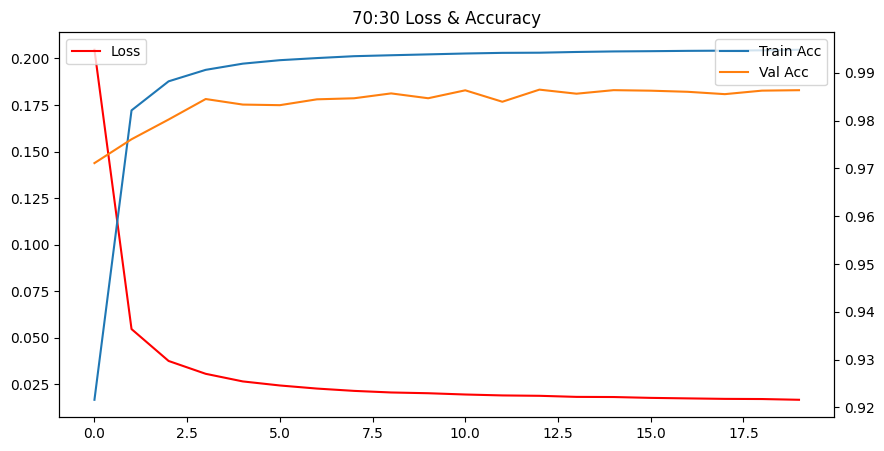

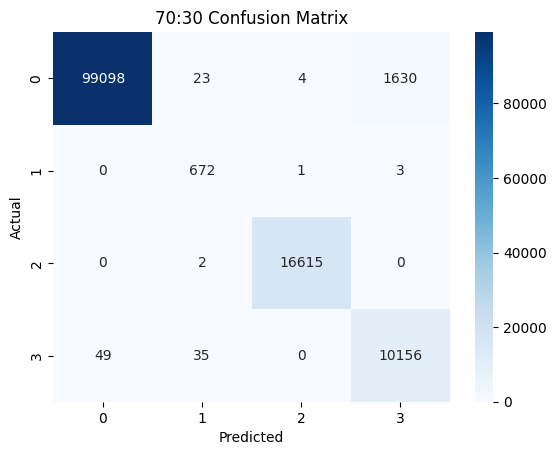

              precision    recall  f1-score   support

           0       1.00      0.98      0.99    100755
           1       0.92      0.99      0.95       676
           2       1.00      1.00      1.00     16617
           3       0.86      0.99      0.92     10240

    accuracy                           0.99    128288
   macro avg       0.94      0.99      0.97    128288
weighted avg       0.99      0.99      0.99    128288



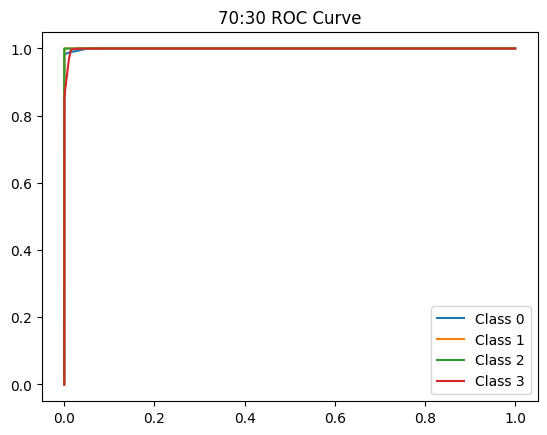

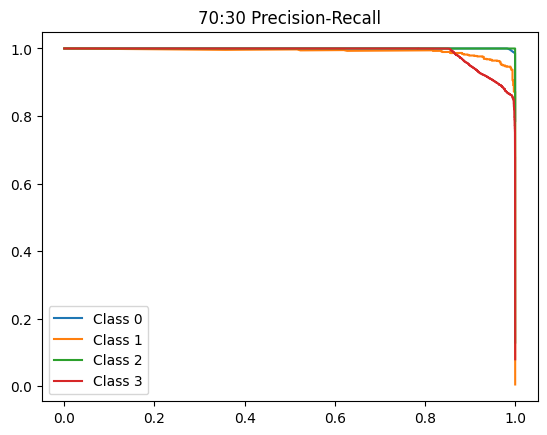


Runtime: 1543.48s
RAM Used: -66.16 MB

========== 80:20 ==========

📊 Original Dataset Size:
Total Samples: 427625

📊 After Train-Test Split:
Train Size: (342100, 24)
Test Size : (85525, 24)

📊 Before ADASYN:
Training Samples: (342100, 24)


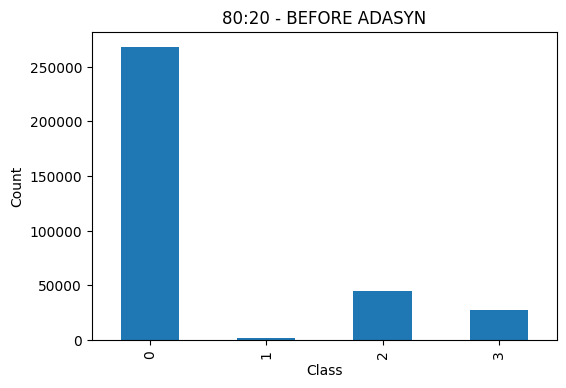

0    268678
1      1803
2     44312
3     27307
Name: count, dtype: int64

📊 After ADASYN:
Training Samples: (1076489, 24)


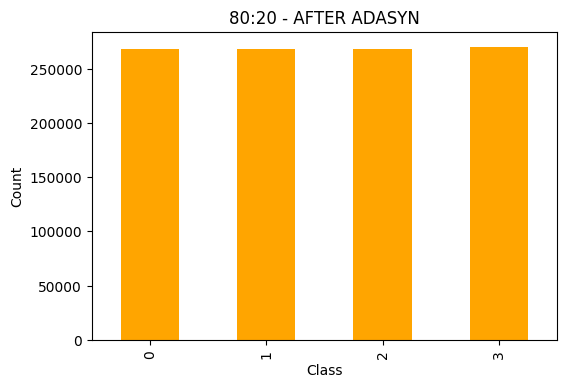

0    268678
1    268367
2    268712
3    270732
Name: count, dtype: int64
Epoch 1: Loss=0.1922, TrainAcc=0.9271, TestAcc=0.9730, ROC-AUC=0.9991
Epoch 2: Loss=0.0465, TrainAcc=0.9859, TestAcc=0.9815, ROC-AUC=0.9993
Epoch 3: Loss=0.0322, TrainAcc=0.9905, TestAcc=0.9836, ROC-AUC=0.9995
Epoch 4: Loss=0.0265, TrainAcc=0.9923, TestAcc=0.9830, ROC-AUC=0.9995
Epoch 5: Loss=0.0234, TrainAcc=0.9931, TestAcc=0.9844, ROC-AUC=0.9995
Epoch 6: Loss=0.0217, TrainAcc=0.9936, TestAcc=0.9844, ROC-AUC=0.9994
Epoch 7: Loss=0.0207, TrainAcc=0.9938, TestAcc=0.9858, ROC-AUC=0.9996
Epoch 8: Loss=0.0200, TrainAcc=0.9941, TestAcc=0.9855, ROC-AUC=0.9995
Epoch 9: Loss=0.0191, TrainAcc=0.9942, TestAcc=0.9860, ROC-AUC=0.9996
Epoch 10: Loss=0.0192, TrainAcc=0.9943, TestAcc=0.9862, ROC-AUC=0.9996
Epoch 11: Loss=0.0183, TrainAcc=0.9945, TestAcc=0.9855, ROC-AUC=0.9995
Epoch 12: Loss=0.0178, TrainAcc=0.9946, TestAcc=0.9855, ROC-AUC=0.9995
Epoch 13: Loss=0.0177, TrainAcc=0.9947, TestAcc=0.9862, ROC-AUC=0.9995
Epoch 14: Lo

In [ ]:
# ----------------- RUN -----------------
df = clean_dataframe(pd.read_csv(DATA_PATH))

run_split_adasyn(df, "60:40", 0.4)
run_split_adasyn(df, "70:30", 0.3)



========== 80:20 ==========

📊 Original Dataset Size:
Total Samples: 427625

📊 After Train-Test Split:
Train Size: (342100, 24)
Test Size : (85525, 24)

📊 Before ADASYN:
Training Samples: (342100, 24)


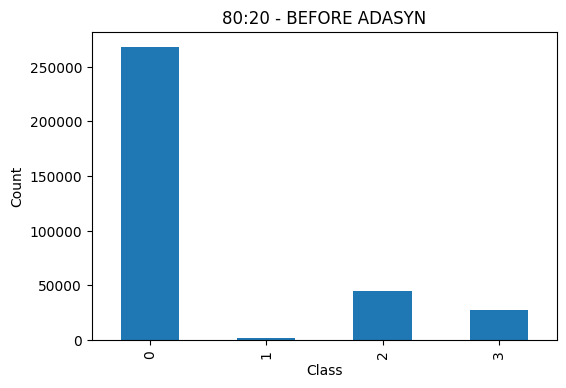

0    268678
1      1803
2     44312
3     27307
Name: count, dtype: int64

📊 After ADASYN:
Training Samples: (1076489, 24)


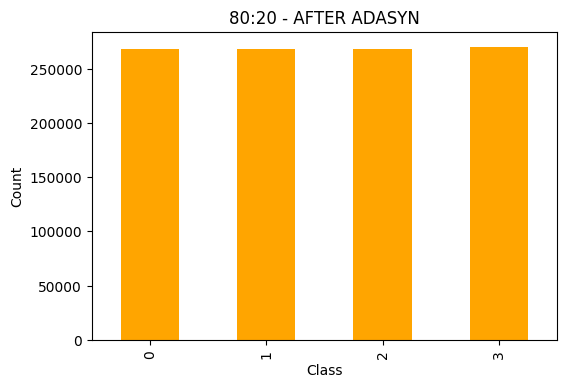

0    268678
1    268367
2    268712
3    270732
Name: count, dtype: int64
Epoch 1: Loss=0.1643, TrainAcc=0.9382, TestAcc=0.9716, ROC-AUC=0.9990
Epoch 2: Loss=0.0446, TrainAcc=0.9865, TestAcc=0.9783, ROC-AUC=0.9992
Epoch 3: Loss=0.0340, TrainAcc=0.9900, TestAcc=0.9837, ROC-AUC=0.9994
Epoch 4: Loss=0.0291, TrainAcc=0.9915, TestAcc=0.9824, ROC-AUC=0.9994
Epoch 5: Loss=0.0265, TrainAcc=0.9923, TestAcc=0.9836, ROC-AUC=0.9995
Epoch 6: Loss=0.0243, TrainAcc=0.9929, TestAcc=0.9840, ROC-AUC=0.9994
Epoch 7: Loss=0.0227, TrainAcc=0.9933, TestAcc=0.9855, ROC-AUC=0.9995
Epoch 8: Loss=0.0217, TrainAcc=0.9937, TestAcc=0.9850, ROC-AUC=0.9995
Epoch 9: Loss=0.0212, TrainAcc=0.9938, TestAcc=0.9845, ROC-AUC=0.9994
Epoch 10: Loss=0.0203, TrainAcc=0.9940, TestAcc=0.9849, ROC-AUC=0.9996
Epoch 11: Loss=0.0199, TrainAcc=0.9941, TestAcc=0.9847, ROC-AUC=0.9995
Epoch 12: Loss=0.0193, TrainAcc=0.9943, TestAcc=0.9861, ROC-AUC=0.9995
Epoch 13: Loss=0.0188, TrainAcc=0.9945, TestAcc=0.9860, ROC-AUC=0.9996
Epoch 14: Lo

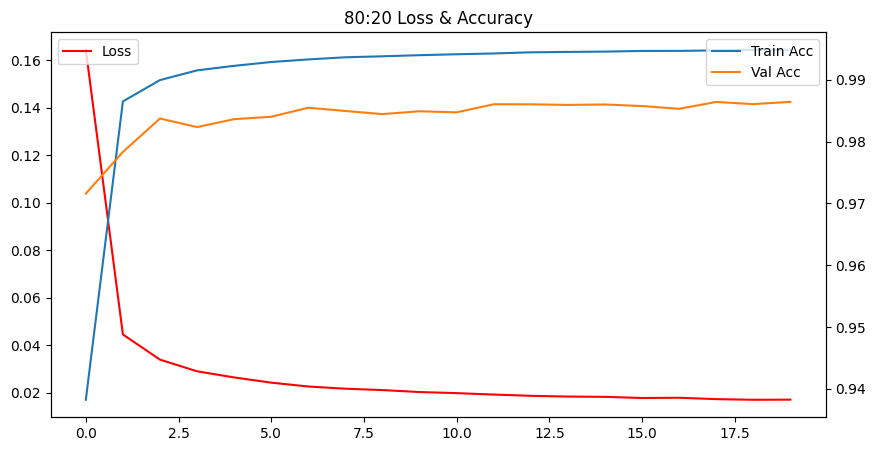

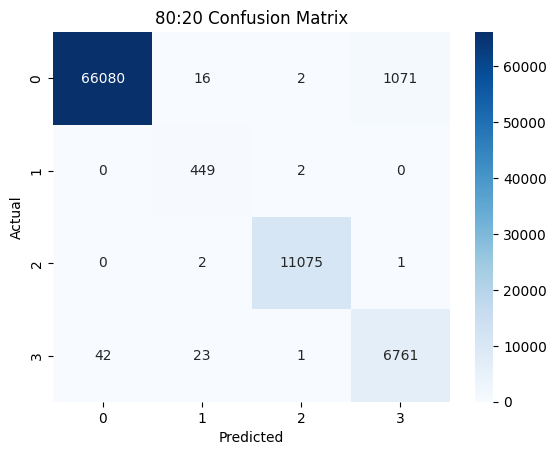

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     67169
           1       0.92      1.00      0.95       451
           2       1.00      1.00      1.00     11078
           3       0.86      0.99      0.92      6827

    accuracy                           0.99     85525
   macro avg       0.94      0.99      0.97     85525
weighted avg       0.99      0.99      0.99     85525



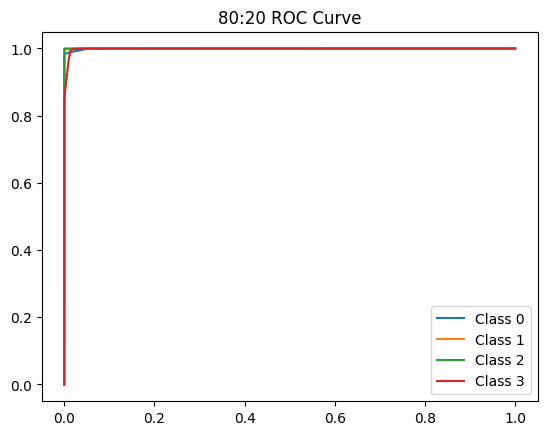

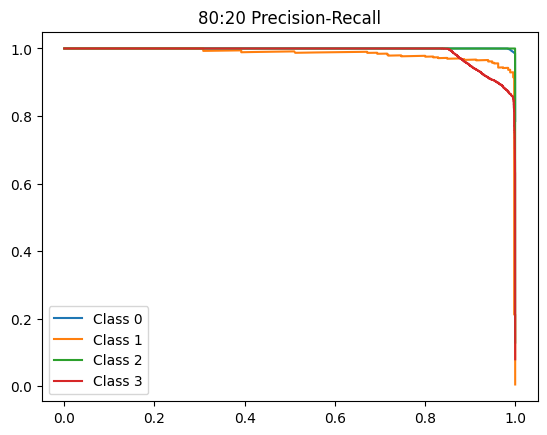


Runtime: 1623.90s
RAM Used: 1210.60 MB


In [10]:
df = clean_dataframe(pd.read_csv(DATA_PATH))
run_split_adasyn(df, "80:20", 0.2)

# ADASYN + TomekLinks

In [20]:
from imblearn.over_sampling import ADASYN
from imblearn.under_sampling import TomekLinks

def run_split_adasyn_tomek(df, ratio_name, test_size, epochs=20):

    print(f"\n========== {ratio_name} ==========")

    start_time = time.time()
    process = psutil.Process(os.getpid())
    start_ram = process.memory_info().rss / (1024 ** 2)

    X = df.drop("label", axis=1).values
    y = df["label"].values
    num_classes = len(np.unique(y))

    # ----------------- ORIGINAL SIZE -----------------
    print("\n📊 Original Dataset Size:")
    print(f"Total Samples: {len(X)}")

    # ----------------- TRAIN TEST SPLIT -----------------
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=42
    )

    print("\n📊 After Train-Test Split:")
    print(f"Train Size: {X_train.shape}")
    print(f"Test Size : {X_test.shape}")

    # ----------------- BEFORE SAMPLING -----------------
    print("\n📊 Before ADASYN + TomekLinks:")
    print(f"Training Samples: {X_train.shape}")

    plt.figure(figsize=(6,4))
    pd.Series(y_train).value_counts().sort_index().plot(kind="bar")
    plt.title(f"{ratio_name} - BEFORE ADASYN + TomekLinks")
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.show()

    print(pd.Series(y_train).value_counts().sort_index())

    # ----------------- ADASYN + TOMEK LINKS -----------------
    try:
        # Step 1: ADASYN
        adasyn = ADASYN(random_state=42)
        X_train, y_train = adasyn.fit_resample(X_train, y_train)

        print("\n📊 After ADASYN:")
        print(pd.Series(y_train).value_counts().sort_index())

        # Step 2: Tomek Links
        tomek = TomekLinks()
        X_train, y_train = tomek.fit_resample(X_train, y_train)

    except Exception as e:
        raise e  # don't silently ignore errors

    # ----------------- AFTER SAMPLING -----------------
    print("\n📊 After ADASYN + TomekLinks:")
    print(f"Training Samples: {X_train.shape}")

    plt.figure(figsize=(6,4))
    pd.Series(y_train).value_counts().sort_index().plot(kind="bar", color="orange")
    plt.title(f"{ratio_name} - AFTER ADASYN + TomekLinks")
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.show()

    print(pd.Series(y_train).value_counts().sort_index())

    # ----------------- SCALING -----------------
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # ----------------- LOADERS -----------------
    train_loader = DataLoader(CustomDataset(X_train, y_train), batch_size=64, shuffle=True)
    test_loader = DataLoader(CustomDataset(X_test, y_test), batch_size=64)

    # ----------------- MODEL -----------------
    model = RobustParallelModel(X.shape[1], 64, num_classes).to(device)

    class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
    class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    history = {"loss": [], "train_acc": [], "val_acc": []}

    # ----------------- TRAINING LOOP -----------------
    for epoch in range(epochs):
        loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
        val_acc, roc_auc, preds, true, probs = evaluate(model, test_loader)

        history["loss"].append(loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}: Loss={loss:.4f}, TrainAcc={train_acc:.4f}, TestAcc={val_acc:.4f}, ROC-AUC={roc_auc:.4f}")

    # ----------------- LOSS & ACCURACY -----------------
    fig, ax1 = plt.subplots(figsize=(10,5))
    ax1.plot(history["loss"], label="Loss", color="red")

    ax2 = ax1.twinx()
    ax2.plot(history["train_acc"], label="Train Acc")
    ax2.plot(history["val_acc"], label="Val Acc")

    ax1.legend(loc="upper left")
    ax2.legend(loc="upper right")

    plt.title(f"{ratio_name} Loss & Accuracy")
    plt.show()

    # ----------------- CONFUSION MATRIX -----------------
    cm = confusion_matrix(true, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{ratio_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    print(classification_report(true, preds))

    # ----------------- ROC CURVE -----------------
    y_test_bin = label_binarize(true, classes=np.arange(num_classes))

    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], probs[:, i])
        plt.plot(fpr, tpr, label=f"Class {i}")

    plt.legend()
    plt.title(f"{ratio_name} ROC Curve")
    plt.show()

    # ----------------- PRECISION-RECALL -----------------
    for i in range(num_classes):
        precision, recall, _ = precision_recall_curve(y_test_bin[:, i], probs[:, i])
        plt.plot(recall, precision, label=f"Class {i}")

    plt.legend()
    plt.title(f"{ratio_name} Precision-Recall")
    plt.show()

    # ----------------- STATS -----------------
    end_time = time.time()
    end_ram = process.memory_info().rss / (1024 ** 2)

    print(f"\nRuntime: {end_time - start_time:.2f}s")
    print(f"RAM Used: {end_ram - start_ram:.2f} MB")


========== 60:40 ==========

📊 Original Dataset Size:
Total Samples: 427625

📊 After Train-Test Split:
Train Size: (256575, 24)
Test Size : (171050, 24)

📊 Before ADASYN + TomekLinks:
Training Samples: (256575, 24)


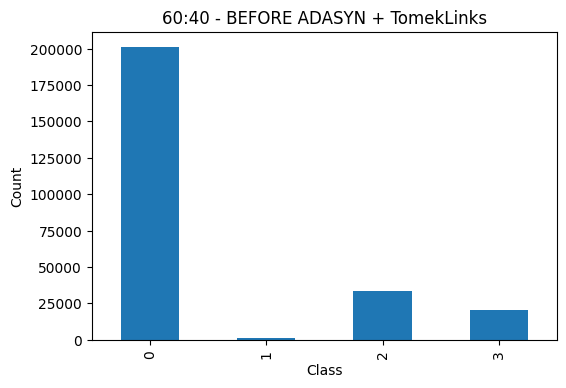

0    201508
1      1353
2     33234
3     20480
Name: count, dtype: int64

📊 After ADASYN:
0    201508
1    201439
2    201546
3    200949
Name: count, dtype: int64

📊 After ADASYN + TomekLinks:
Training Samples: (796541, 24)


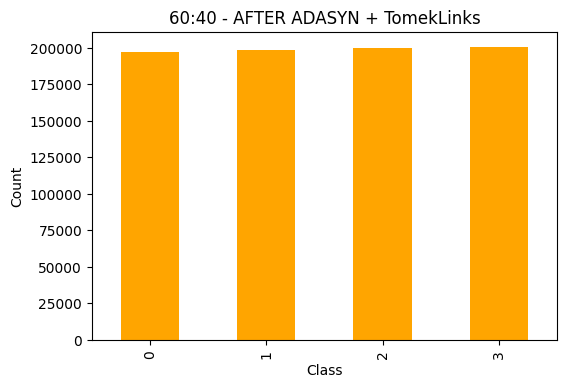

0    197264
1    198377
2    199951
3    200949
Name: count, dtype: int64
Epoch 1: Loss=0.2041, TrainAcc=0.9264, TestAcc=0.9730, ROC-AUC=0.9981
Epoch 2: Loss=0.0631, TrainAcc=0.9803, TestAcc=0.9783, ROC-AUC=0.9990
Epoch 3: Loss=0.0404, TrainAcc=0.9877, TestAcc=0.9832, ROC-AUC=0.9993
Epoch 4: Loss=0.0309, TrainAcc=0.9909, TestAcc=0.9814, ROC-AUC=0.9993
Epoch 5: Loss=0.0268, TrainAcc=0.9922, TestAcc=0.9843, ROC-AUC=0.9994
Epoch 6: Loss=0.0239, TrainAcc=0.9930, TestAcc=0.9820, ROC-AUC=0.9991
Epoch 7: Loss=0.0221, TrainAcc=0.9935, TestAcc=0.9840, ROC-AUC=0.9995
Epoch 8: Loss=0.0206, TrainAcc=0.9940, TestAcc=0.9856, ROC-AUC=0.9995
Epoch 9: Loss=0.0193, TrainAcc=0.9942, TestAcc=0.9844, ROC-AUC=0.9995
Epoch 10: Loss=0.0186, TrainAcc=0.9945, TestAcc=0.9854, ROC-AUC=0.9995
Epoch 11: Loss=0.0179, TrainAcc=0.9947, TestAcc=0.9848, ROC-AUC=0.9995
Epoch 12: Loss=0.0175, TrainAcc=0.9948, TestAcc=0.9856, ROC-AUC=0.9995
Epoch 13: Loss=0.0170, TrainAcc=0.9949, TestAcc=0.9859, ROC-AUC=0.9995
Epoch 14: Lo

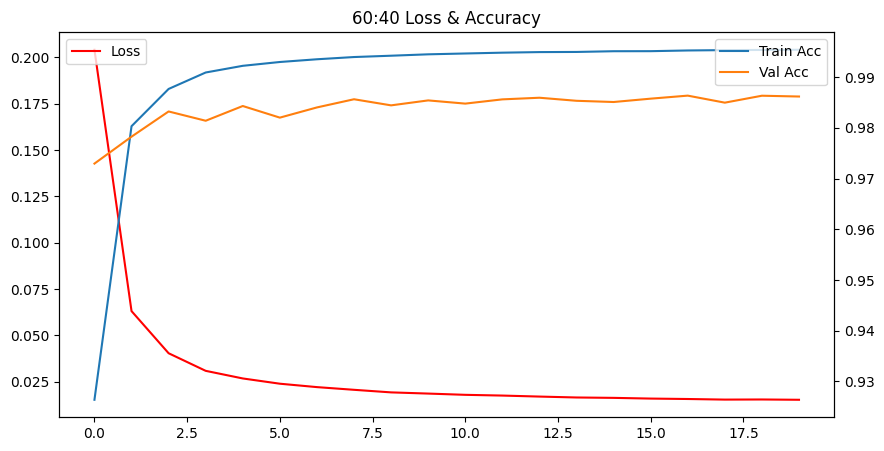

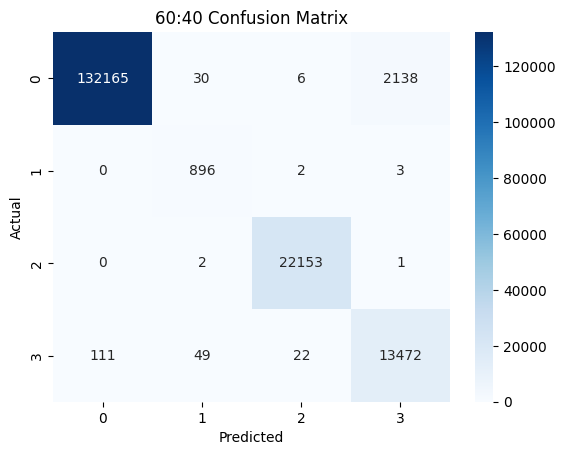

              precision    recall  f1-score   support

           0       1.00      0.98      0.99    134339
           1       0.92      0.99      0.95       901
           2       1.00      1.00      1.00     22156
           3       0.86      0.99      0.92     13654

    accuracy                           0.99    171050
   macro avg       0.94      0.99      0.97    171050
weighted avg       0.99      0.99      0.99    171050



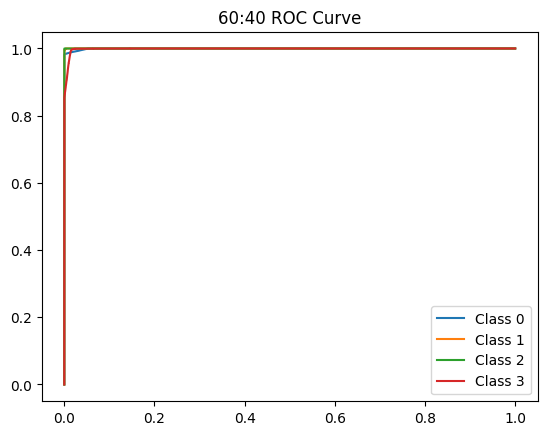

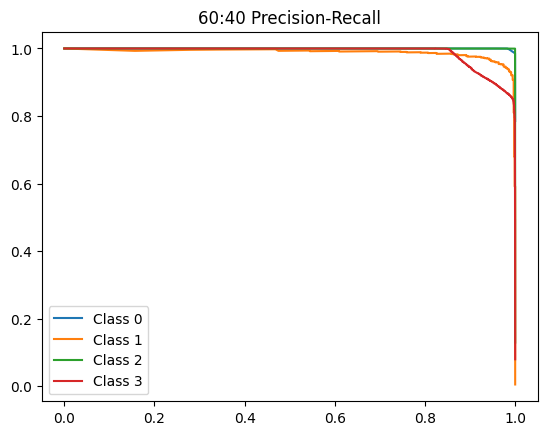


Runtime: 2923.66s
RAM Used: 439.68 MB

========== 70:30 ==========

📊 Original Dataset Size:
Total Samples: 427625

📊 After Train-Test Split:
Train Size: (299337, 24)
Test Size : (128288, 24)

📊 Before ADASYN + TomekLinks:
Training Samples: (299337, 24)


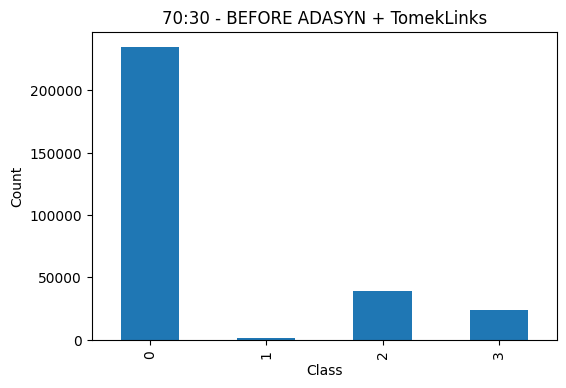

0    235092
1      1578
2     38773
3     23894
Name: count, dtype: int64

📊 After ADASYN:
0    235092
1    235149
2    235089
3    236755
Name: count, dtype: int64

📊 After ADASYN + TomekLinks:
Training Samples: (931135, 24)


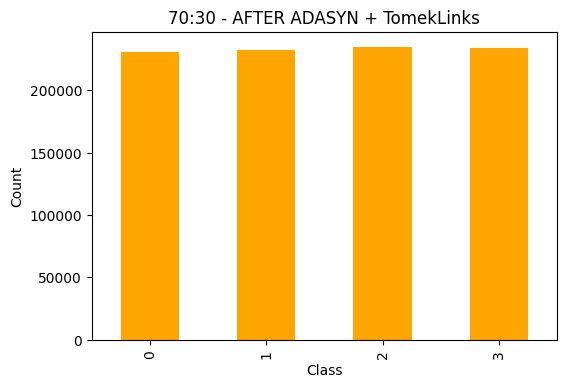

0    230618
1    231924
2    235089
3    233504
Name: count, dtype: int64
Epoch 1: Loss=0.1924, TrainAcc=0.9293, TestAcc=0.9736, ROC-AUC=0.9988
Epoch 2: Loss=0.0598, TrainAcc=0.9808, TestAcc=0.9746, ROC-AUC=0.9994
Epoch 3: Loss=0.0377, TrainAcc=0.9885, TestAcc=0.9805, ROC-AUC=0.9994
Epoch 4: Loss=0.0292, TrainAcc=0.9914, TestAcc=0.9819, ROC-AUC=0.9994
Epoch 5: Loss=0.0254, TrainAcc=0.9925, TestAcc=0.9825, ROC-AUC=0.9993
Epoch 6: Loss=0.0229, TrainAcc=0.9933, TestAcc=0.9847, ROC-AUC=0.9995
Epoch 7: Loss=0.0211, TrainAcc=0.9938, TestAcc=0.9839, ROC-AUC=0.9994
Epoch 8: Loss=0.0200, TrainAcc=0.9942, TestAcc=0.9858, ROC-AUC=0.9995
Epoch 9: Loss=0.0191, TrainAcc=0.9944, TestAcc=0.9850, ROC-AUC=0.9995
Epoch 10: Loss=0.0184, TrainAcc=0.9946, TestAcc=0.9858, ROC-AUC=0.9996
Epoch 11: Loss=0.0180, TrainAcc=0.9947, TestAcc=0.9842, ROC-AUC=0.9995
Epoch 12: Loss=0.0178, TrainAcc=0.9949, TestAcc=0.9861, ROC-AUC=0.9996
Epoch 13: Loss=0.0170, TrainAcc=0.9950, TestAcc=0.9860, ROC-AUC=0.9996
Epoch 14: Lo

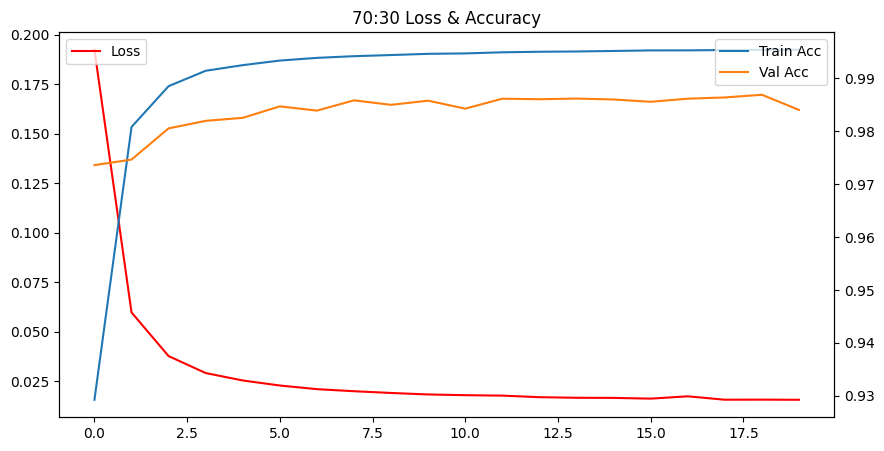

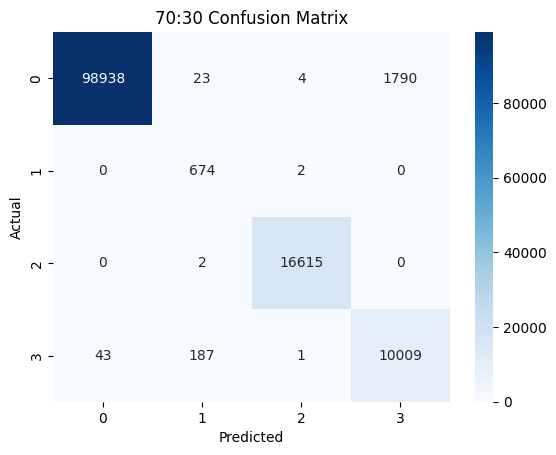

              precision    recall  f1-score   support

           0       1.00      0.98      0.99    100755
           1       0.76      1.00      0.86       676
           2       1.00      1.00      1.00     16617
           3       0.85      0.98      0.91     10240

    accuracy                           0.98    128288
   macro avg       0.90      0.99      0.94    128288
weighted avg       0.99      0.98      0.98    128288



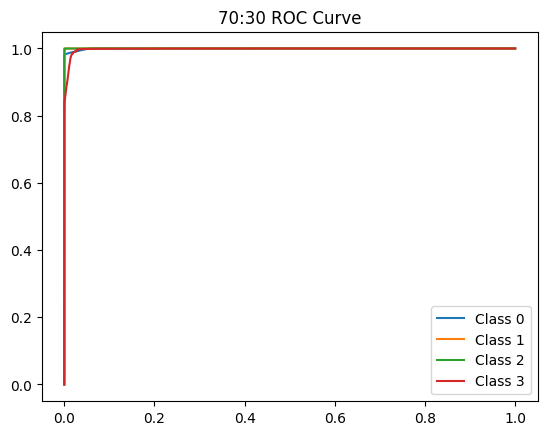

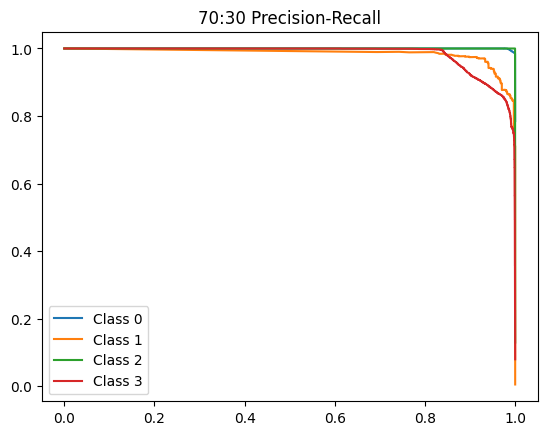


Runtime: 3785.70s
RAM Used: -3.09 MB

========== 80:20 ==========

📊 Original Dataset Size:
Total Samples: 427625

📊 After Train-Test Split:
Train Size: (342100, 24)
Test Size : (85525, 24)

📊 Before ADASYN + TomekLinks:
Training Samples: (342100, 24)


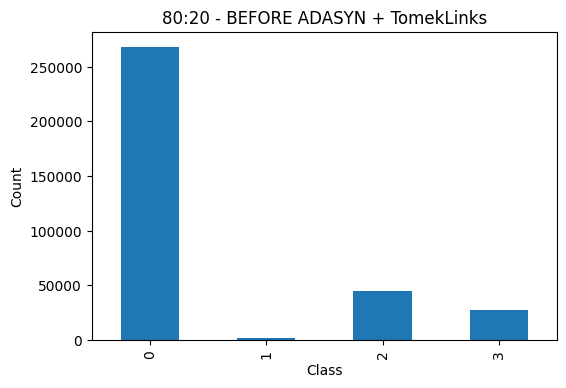

0    268678
1      1803
2     44312
3     27307
Name: count, dtype: int64

📊 After ADASYN:
0    268678
1    268367
2    268712
3    270732
Name: count, dtype: int64

📊 After ADASYN + TomekLinks:
Training Samples: (1068144, 24)


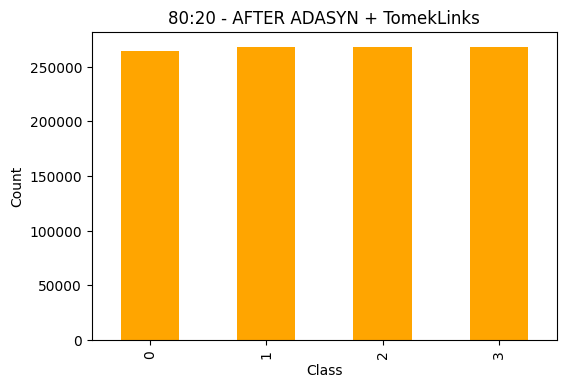

0    264566
1    268367
2    267606
3    267605
Name: count, dtype: int64
Epoch 1: Loss=0.1602, TrainAcc=0.9412, TestAcc=0.9754, ROC-AUC=0.9987
Epoch 2: Loss=0.0414, TrainAcc=0.9874, TestAcc=0.9830, ROC-AUC=0.9993
Epoch 3: Loss=0.0312, TrainAcc=0.9909, TestAcc=0.9833, ROC-AUC=0.9993
Epoch 4: Loss=0.0269, TrainAcc=0.9922, TestAcc=0.9804, ROC-AUC=0.9993
Epoch 5: Loss=0.0242, TrainAcc=0.9930, TestAcc=0.9845, ROC-AUC=0.9995
Epoch 6: Loss=0.0227, TrainAcc=0.9934, TestAcc=0.9846, ROC-AUC=0.9995
Epoch 7: Loss=0.0213, TrainAcc=0.9939, TestAcc=0.9851, ROC-AUC=0.9995
Epoch 8: Loss=0.0205, TrainAcc=0.9941, TestAcc=0.9846, ROC-AUC=0.9995
Epoch 9: Loss=0.0198, TrainAcc=0.9943, TestAcc=0.9850, ROC-AUC=0.9995
Epoch 10: Loss=0.0192, TrainAcc=0.9944, TestAcc=0.9850, ROC-AUC=0.9995
Epoch 11: Loss=0.0188, TrainAcc=0.9946, TestAcc=0.9859, ROC-AUC=0.9995
Epoch 12: Loss=0.0185, TrainAcc=0.9947, TestAcc=0.9853, ROC-AUC=0.9995
Epoch 13: Loss=0.0180, TrainAcc=0.9948, TestAcc=0.9860, ROC-AUC=0.9996
Epoch 14: Lo

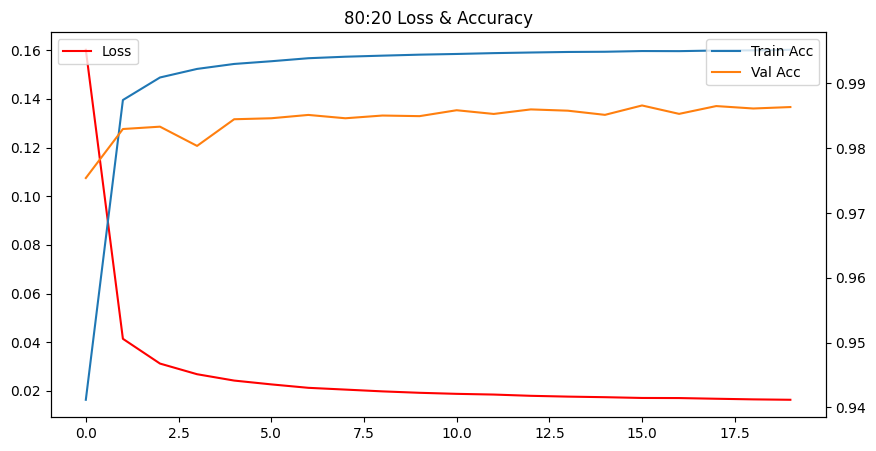

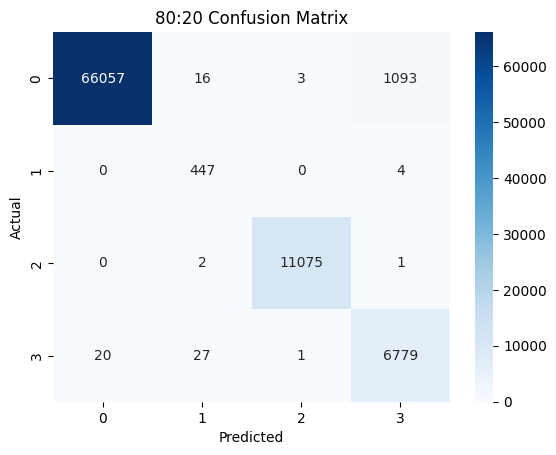

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     67169
           1       0.91      0.99      0.95       451
           2       1.00      1.00      1.00     11078
           3       0.86      0.99      0.92      6827

    accuracy                           0.99     85525
   macro avg       0.94      0.99      0.97     85525
weighted avg       0.99      0.99      0.99     85525



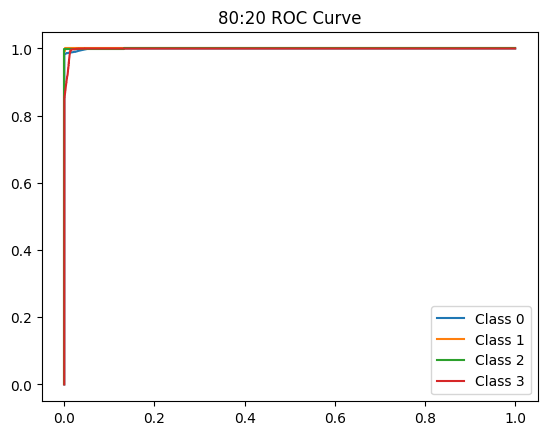

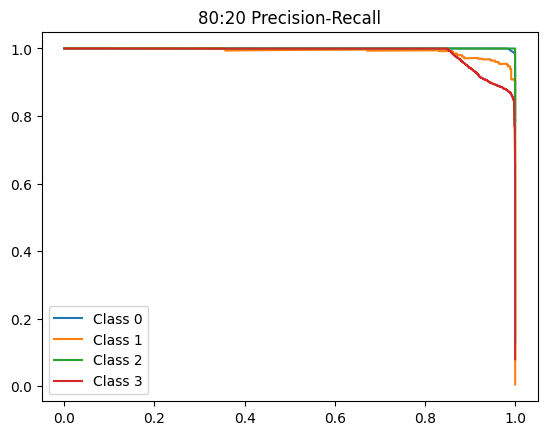


Runtime: 4640.43s
RAM Used: 375.70 MB


In [21]:
# ----------------- RUN -----------------
df = clean_dataframe(pd.read_csv(DATA_PATH))

run_split_adasyn_tomek(df, "60:40", 0.4)
run_split_adasyn_tomek(df, "70:30", 0.3)
run_split_adasyn_tomek(df, "80:20", 0.2)